In [70]:
# Cell 1
# =============================================================================
# Load Artifacts, Test Datasets, Predictions, and Generate Baseline Predictions
# =============================================================================

import os
import joblib
import pandas as pd
import numpy as np

MODELS_DIR = "models"
BASE_DIR = "dataset/normalized"
NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]

# -----------------------------------------------------------------------------
# 1. Load Label Encoder and Context Model Predictions
# -----------------------------------------------------------------------------
le_context = joblib.load(os.path.join(MODELS_DIR, "label_encoder_context.joblib"))
classes = le_context.classes_

df_pred_hw_agg = pd.read_csv(os.path.join(MODELS_DIR, "predictions_test_rf_context_own_hw_plus_agg.csv"))
df_pred_full   = pd.read_csv(os.path.join(MODELS_DIR, "predictions_test_rf_context_full.csv"))

# -----------------------------------------------------------------------------
# 2. Load Baseline Model Artifacts and Predict on Normalized Test Sets
# -----------------------------------------------------------------------------
rf_base = joblib.load(os.path.join(MODELS_DIR, "rf_final.joblib"))
le_base = joblib.load(os.path.join(MODELS_DIR, "label_encoder.joblib"))
scaler_base = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))

# Feature definition for baseline model (own hardware features only)
base_feature_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]
base_numeric_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
base_expected_order = [
    "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
    "State_idle", "State_charging"
]

# Concatenate all node test sets to form the full multi-node test set
test_files = [os.path.join(BASE_DIR, f"Node_{node}_test_normalized.csv") for node in NODES]
df_test_raw = pd.concat([pd.read_csv(p) for p in test_files], ignore_index=True)

# Prepare baseline features
X_base_raw = df_test_raw[base_feature_cols].copy()
X_base_encoded = pd.get_dummies(X_base_raw, columns=["State"], drop_first=False)
for col in ["State_idle", "State_charging"]:
    if col not in X_base_encoded.columns:
        X_base_encoded[col] = 0
X_base_ordered = X_base_encoded[base_expected_order].copy()
X_base_ordered[base_numeric_cols] = scaler_base.transform(X_base_ordered[base_numeric_cols])
X_base_np = X_base_ordered.to_numpy()

# Generate baseline predictions and class probabilities
y_base_pred_idx = rf_base.predict(X_base_np)
y_base_proba = rf_base.predict_proba(X_base_np)

df_pred_base = pd.DataFrame()
df_pred_base["Attack"] = df_test_raw["Attack"]
df_pred_base["prediction"] = le_base.inverse_transform(y_base_pred_idx)
for idx, cls_name in enumerate(le_base.classes_):
    df_pred_base[f"prob_{cls_name}"] = y_base_proba[:, idx]

# Export baseline combined predictions
df_pred_base.to_csv(os.path.join(MODELS_DIR, "predictions_test_rf_baseline.csv"), index=False)

print(f"Loaded label encoder and prediction sets from '{MODELS_DIR}'.")
print(f"Target Attack Classes: {classes}")
print(f"Total Test Samples Evaluated: {len(df_pred_base)}")

Loaded label encoder and prediction sets from 'models'.
Target Attack Classes: ['Backdoor' 'none' 'syn-flood']
Total Test Samples Evaluated: 174408


In [71]:
# Cell 2
# =============================================================================
# Metric Benchmarking: 3-Model Comparison Summary Table
# =============================================================================

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score

def compute_model_metrics(df_preds, model_name):
    """
    Computes standard evaluation metrics: Accuracy, Macro F1, Weighted F1,
    Multi-class Log Loss, and One-vs-Rest Macro ROC-AUC.
    """
    y_true_enc = le_context.transform(df_preds["Attack"])
    y_pred_enc = le_context.transform(df_preds["prediction"])
    
    prob_cols = [f"prob_{cls_name}" for cls_name in classes]
    y_proba = df_preds[prob_cols].values
    
    acc = accuracy_score(y_true_enc, y_pred_enc)
    macro_f1 = f1_score(y_true_enc, y_pred_enc, average="macro")
    weighted_f1 = f1_score(y_true_enc, y_pred_enc, average="weighted")
    loss = log_loss(y_true_enc, y_proba)
    roc_auc = roc_auc_score(y_true_enc, y_proba, multi_class="ovr", average="macro")
    
    return {
        "Model Configuration": model_name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "Log Loss": round(loss, 4),
        "ROC-AUC (Macro OVR)": round(roc_auc, 4)
    }

# Benchmark Baseline RF against both Context-Aware configurations
metrics_summary = [
    compute_model_metrics(df_pred_base, "Baseline RF (Own HW Only)"),
    compute_model_metrics(df_pred_hw_agg, "Context RF (Own HW + Agg Reports)"),
    compute_model_metrics(df_pred_full, "Full Context RF (Own Probs + Agg)")
]

df_metrics = pd.DataFrame(metrics_summary)
print("=== 3-Model Performance Comparison ===")
print(df_metrics.to_string(index=False))

=== 3-Model Performance Comparison ===
              Model Configuration  Accuracy  Macro F1  Weighted F1  Log Loss  ROC-AUC (Macro OVR)
        Baseline RF (Own HW Only)    0.8981    0.8781       0.8955    0.2375               0.9730
Context RF (Own HW + Agg Reports)    0.9382    0.9387       0.9380    0.6734               0.9772
Full Context RF (Own Probs + Agg)    0.9308    0.9315       0.9307    0.8696               0.9781


In [68]:
# Cell 3
# =============================================================================
# Per-Class Precision, Recall, and F1-Score Breakdown for All Models
# =============================================================================

from sklearn.metrics import classification_report

print("=====================================================================")
print(" 1. Baseline Model: Own Hardware Sensor Features Only")
print("=====================================================================")
print(classification_report(df_pred_base["Attack"], df_pred_base["prediction"], digits=4))

print("\n=====================================================================")
print(" 2. Context Model 1: Own Hardware + Aggregated Context Reports")
print("=====================================================================")
print(classification_report(df_pred_hw_agg["Attack"], df_pred_hw_agg["prediction"], digits=4))

print("\n=====================================================================")
print(" 3. Context Model 2: Full Context (Own Probs + Agg Context Reports)")
print("=====================================================================")
print(classification_report(df_pred_full["Attack"], df_pred_full["prediction"], digits=4))

 1. Baseline Model: Own Hardware Sensor Features Only
              precision    recall  f1-score   support

    Backdoor     0.7823    0.6773    0.7260     34476
        none     0.9021    0.9404    0.9209    105456
   syn-flood     0.9854    0.9897    0.9875     34476

    accuracy                         0.8981    174408
   macro avg     0.8899    0.8691    0.8781    174408
weighted avg     0.8949    0.8981    0.8955    174408


 2. Context Model 1: Own Hardware + Aggregated Context Reports
              precision    recall  f1-score   support

    Backdoor     0.8860    0.9494    0.9166     27378
        none     0.9390    0.8645    0.9002     24843
   syn-flood     0.9992    0.9996    0.9994     24843

    accuracy                         0.9382     77064
   macro avg     0.9414    0.9378    0.9387     77064
weighted avg     0.9396    0.9382    0.9380     77064


 3. Context Model 2: Full Context (Own Probs + Agg Context Reports)
              precision    recall  f1-score   suppo

Saved confusion matrix comparison plot to 'plots/confusion_matrices_comparison.png'


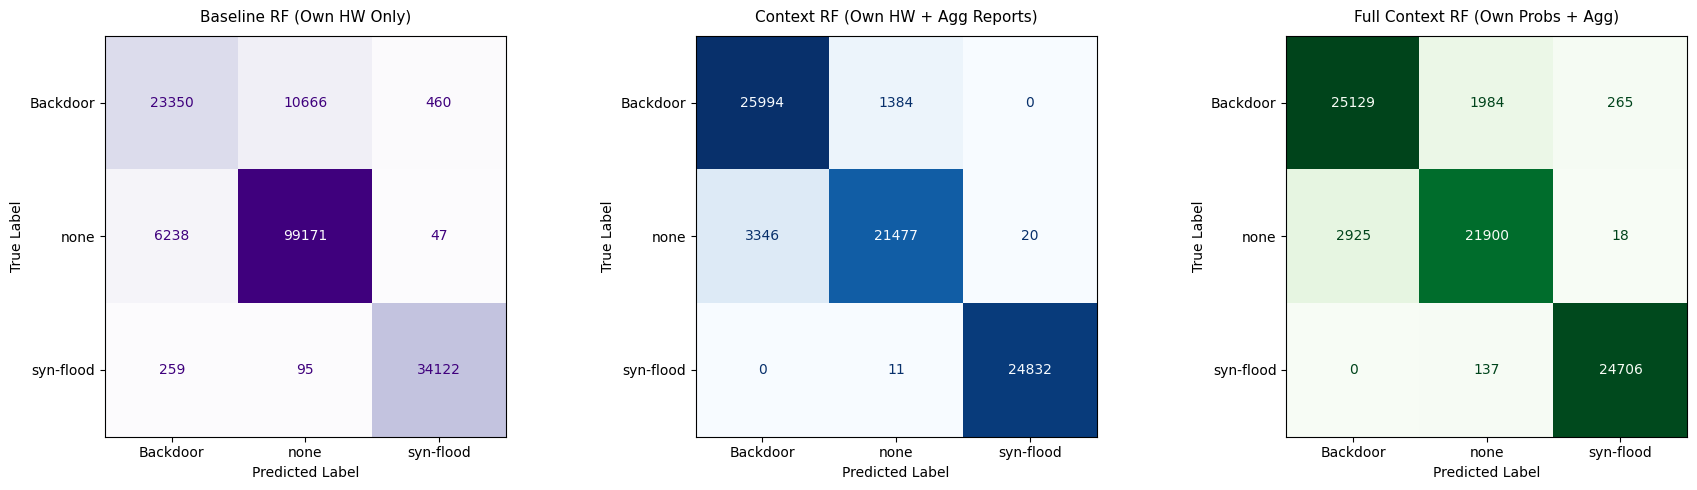

In [69]:
# Cell 4
# =============================================================================
# Side-by-Side Confusion Matrix Plots (Baseline vs. Context Models)
# =============================================================================

import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Baseline RF
cm_base = confusion_matrix(df_pred_base["Attack"], df_pred_base["prediction"], labels=classes)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=classes)
disp_base.plot(ax=axes[0], cmap="Purples", values_format="d", colorbar=False)
axes[0].set_title("Baseline RF (Own HW Only)", fontsize=11, pad=10)
axes[0].set_xlabel("Predicted Label", fontsize=10)
axes[0].set_ylabel("True Label", fontsize=10)

# Model 1: Own HW + Agg Context
cm1 = confusion_matrix(df_pred_hw_agg["Attack"], df_pred_hw_agg["prediction"], labels=classes)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=classes)
disp1.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("Context RF (Own HW + Agg Reports)", fontsize=11, pad=10)
axes[1].set_xlabel("Predicted Label", fontsize=10)
axes[1].set_ylabel("True Label", fontsize=10)

# Model 2: Full Context
cm2 = confusion_matrix(df_pred_full["Attack"], df_pred_full["prediction"], labels=classes)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=classes)
disp2.plot(ax=axes[2], cmap="Greens", values_format="d", colorbar=False)
axes[2].set_title("Full Context RF (Own Probs + Agg)", fontsize=11, pad=10)
axes[2].set_xlabel("Predicted Label", fontsize=10)
axes[2].set_ylabel("True Label", fontsize=10)

plt.tight_layout()

# Save the plot
output_path = os.path.join(PLOTS_DIR, "confusion_matrices_comparison.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix comparison plot to '{output_path}'")

plt.show()
plt.close(fig)

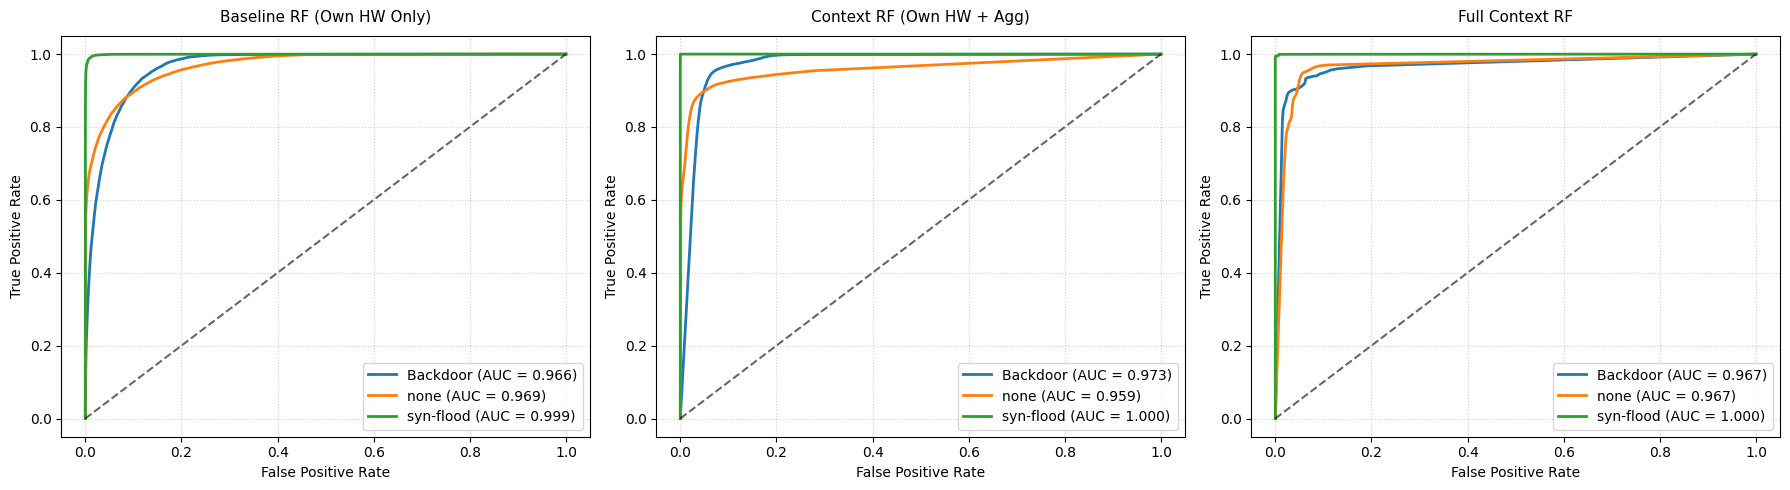

In [58]:
# Cell 5
# =============================================================================
# Multiclass ROC Curves Comparison (Baseline vs. Context Models)
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(le_context.transform(df_pred_base["Attack"]), classes=range(len(classes)))
prob_cols = [f"prob_{cls_name}" for cls_name in classes]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_dfs = [
    (df_pred_base, "Baseline RF (Own HW Only)", axes[0]),
    (df_pred_hw_agg, "Context RF (Own HW + Agg)", axes[1]),
    (df_pred_full, "Full Context RF", axes[2])
]

for df_preds, title, ax in model_dfs:
    y_prob = df_preds[prob_cols].values
    for i, cls_name in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_score = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{cls_name} (AUC = {roc_score:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.6)
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.legend(loc="lower right", frameon=True)
    ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

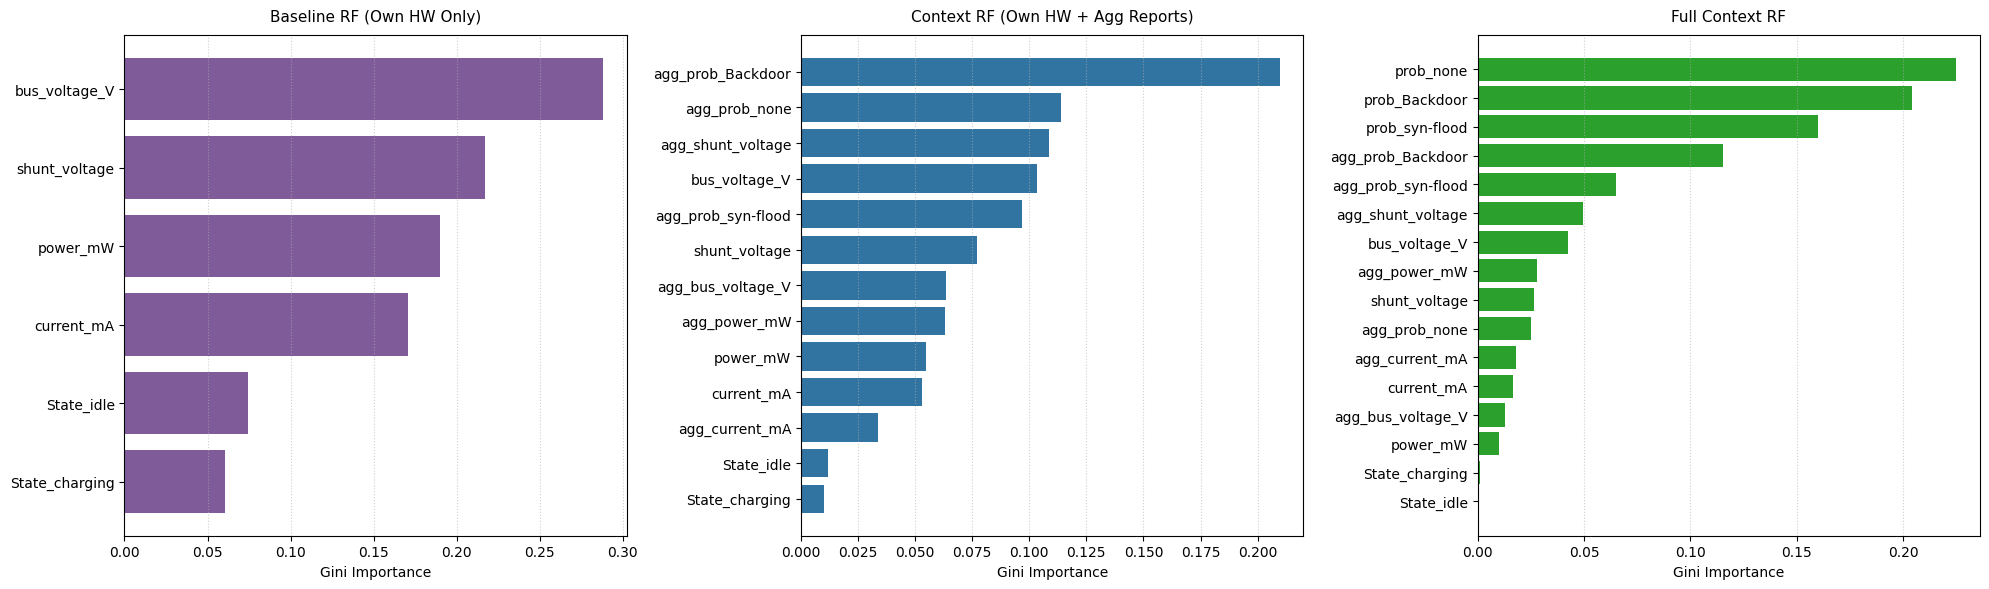

In [59]:
# Cell 6
# =============================================================================
# Feature Importance Comparison Across All 3 Model Variations
# =============================================================================

import os
import joblib
import matplotlib.pyplot as plt
import pandas as pd

MODELS_DIR = "models"

# Load models
rf_base   = joblib.load(os.path.join(MODELS_DIR, "rf_final.joblib"))
rf_hw_agg = joblib.load(os.path.join(MODELS_DIR, "rf_context_own_hw_plus_agg.joblib"))
rf_full   = joblib.load(os.path.join(MODELS_DIR, "rf_context_full.joblib"))

# Feature lists
feat_base   = [
    "shunt_voltage", "bus_voltage_V", "current_mA", "power_mW",
    "State_idle", "State_charging"
]
feat_hw_agg = pd.read_csv(os.path.join(MODELS_DIR, "feature_list_own_hw_plus_agg.csv"))["feature"].tolist()
feat_full   = pd.read_csv(os.path.join(MODELS_DIR, "feature_list_context_full.csv"))["feature"].tolist()

# Prepare DataFrames
df_imp_base = pd.DataFrame({"Feature": feat_base,   "Importance": rf_base.feature_importances_}).sort_values("Importance", ascending=True)
df_imp_1    = pd.DataFrame({"Feature": feat_hw_agg, "Importance": rf_hw_agg.feature_importances_}).sort_values("Importance", ascending=True)
df_imp_2    = pd.DataFrame({"Feature": feat_full,   "Importance": rf_full.feature_importances_}).sort_values("Importance", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].barh(df_imp_base["Feature"], df_imp_base["Importance"], color="#805B9A")
axes[0].set_title("Baseline RF (Own HW Only)", fontsize=11, pad=10)
axes[0].set_xlabel("Gini Importance", fontsize=10)
axes[0].grid(True, axis="x", linestyle=":", alpha=0.6)

axes[1].barh(df_imp_1["Feature"], df_imp_1["Importance"], color="#3274A1")
axes[1].set_title("Context RF (Own HW + Agg Reports)", fontsize=11, pad=10)
axes[1].set_xlabel("Gini Importance", fontsize=10)
axes[1].grid(True, axis="x", linestyle=":", alpha=0.6)

axes[2].barh(df_imp_2["Feature"], df_imp_2["Importance"], color="#2CA02C")
axes[2].set_title("Full Context RF", fontsize=11, pad=10)
axes[2].set_xlabel("Gini Importance", fontsize=10)
axes[2].grid(True, axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

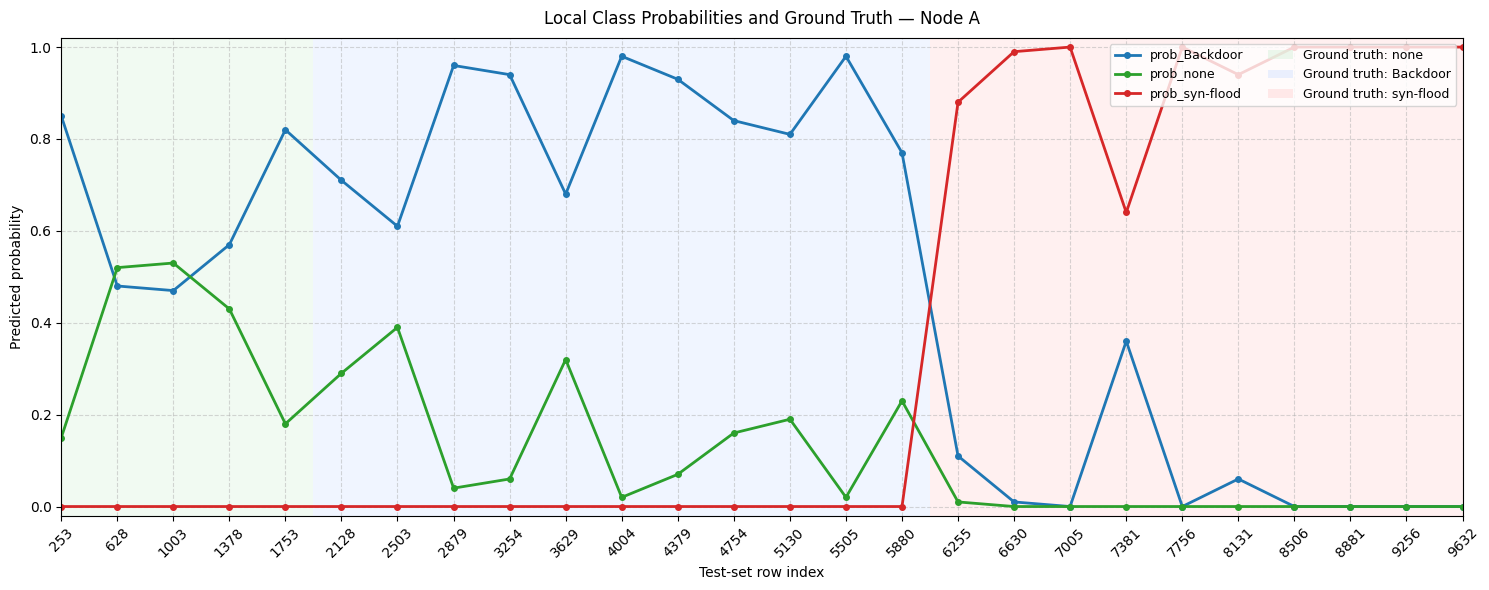

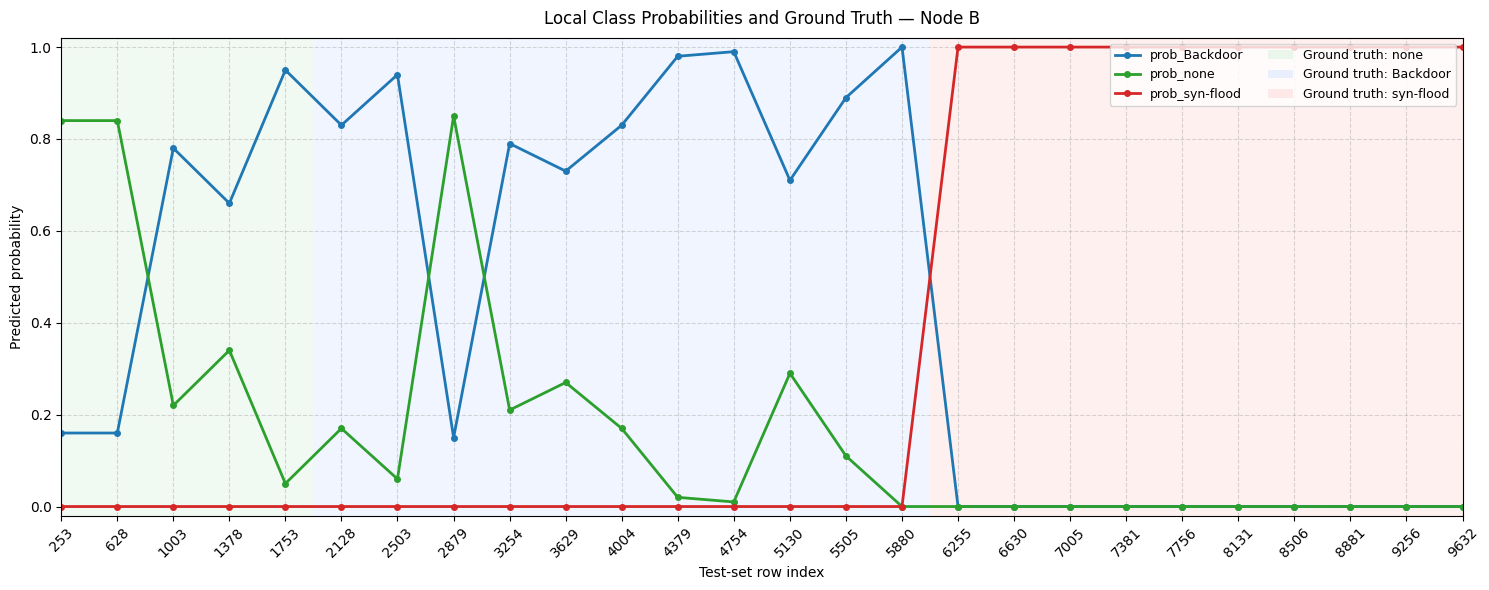

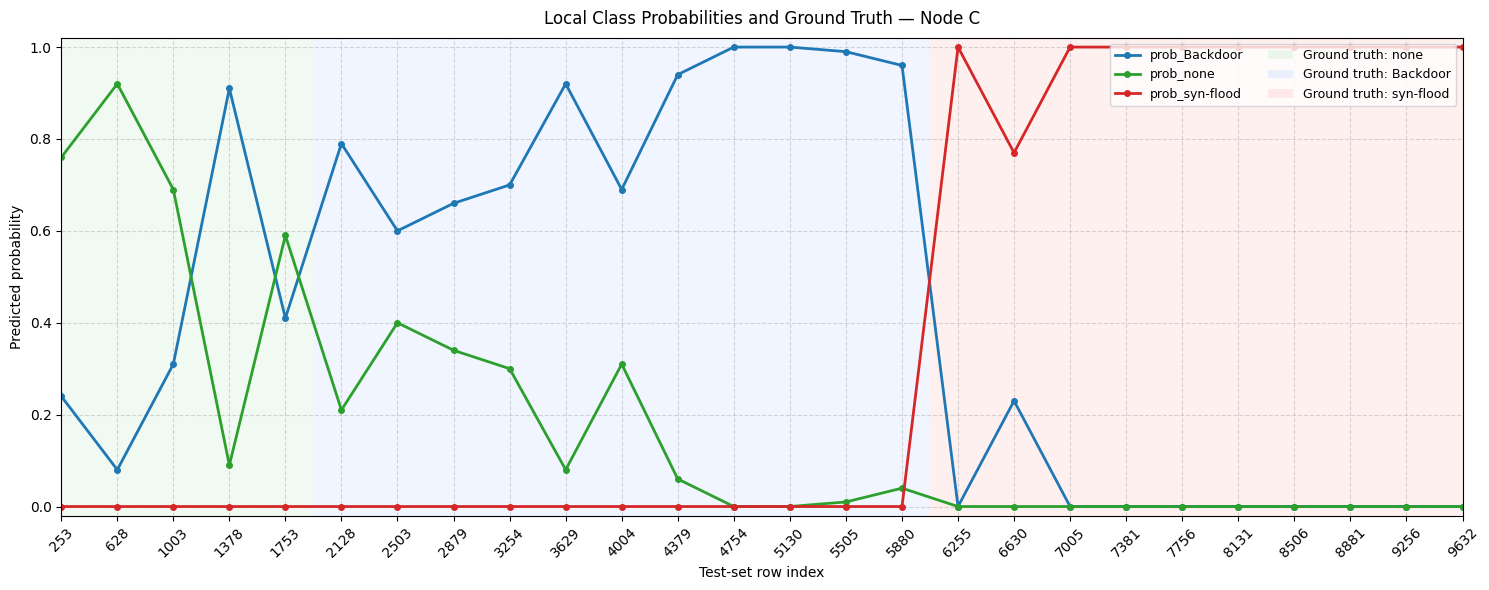

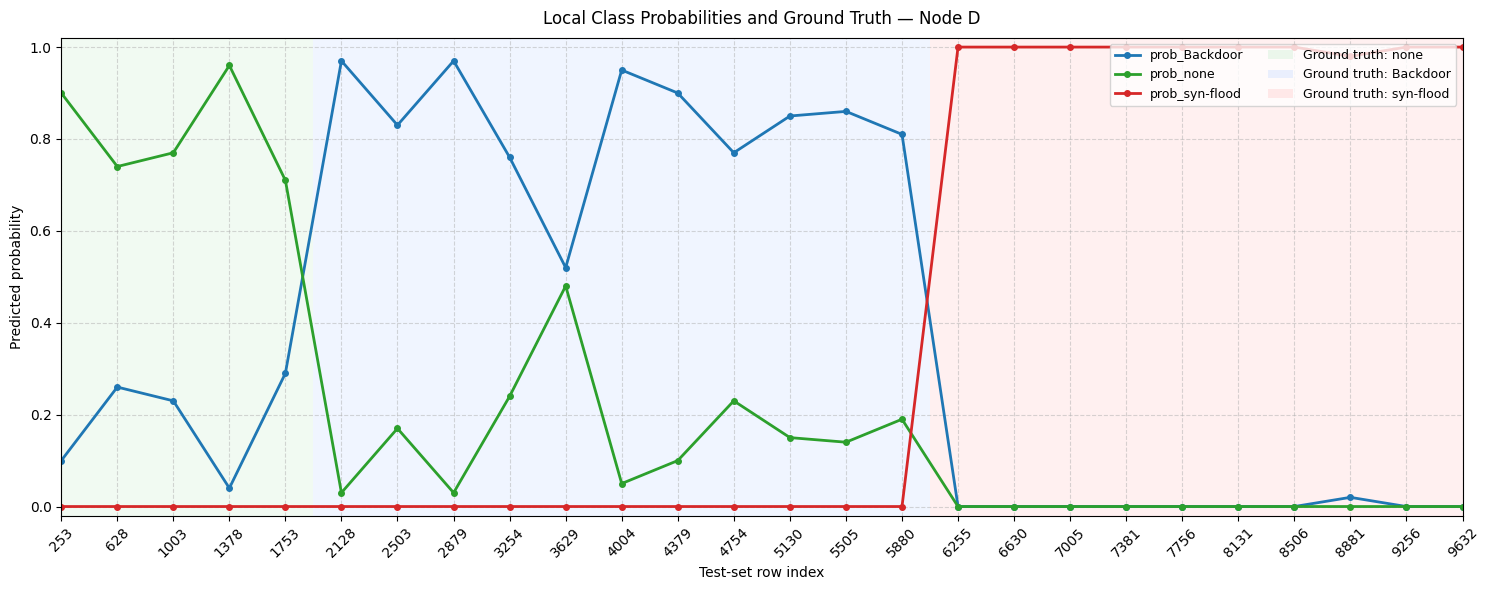

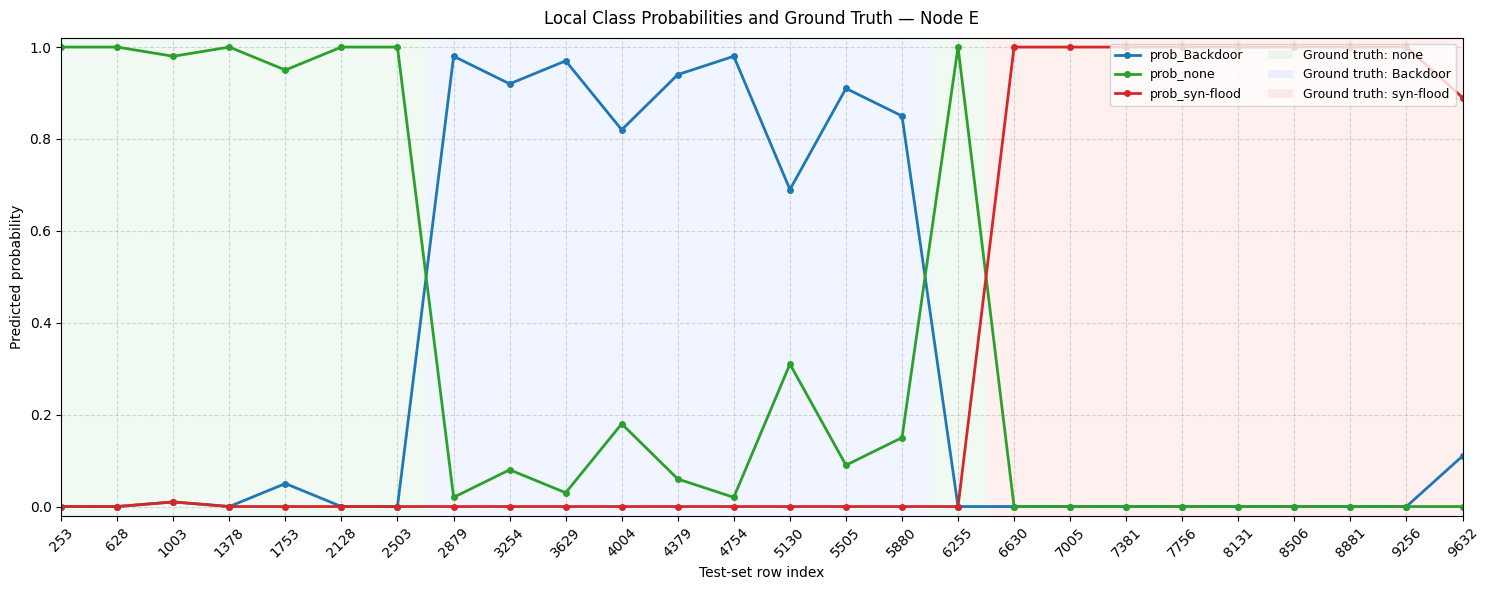

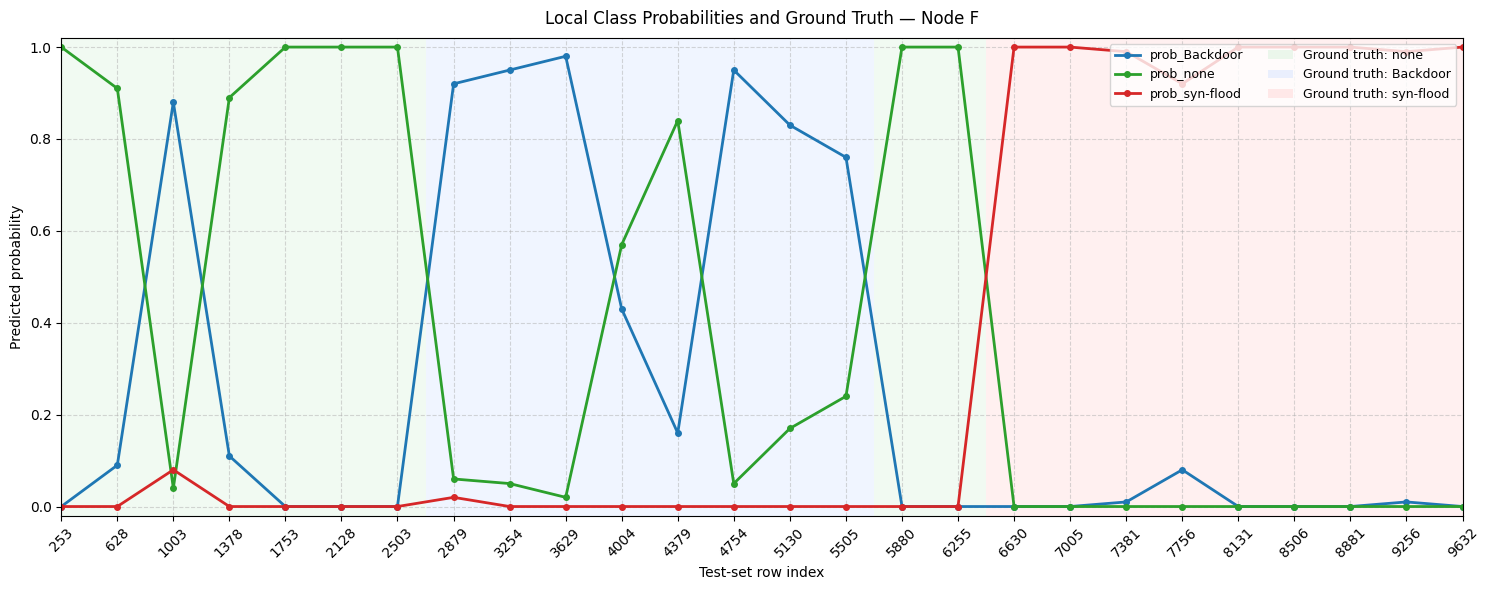

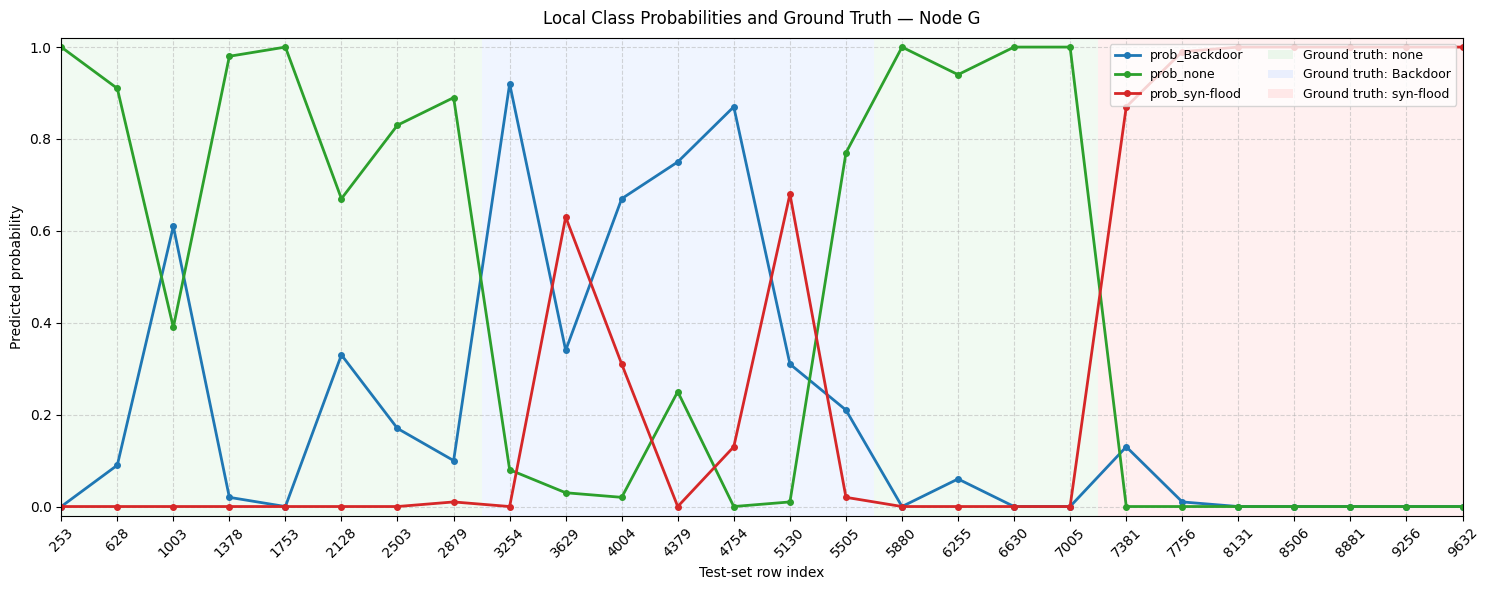

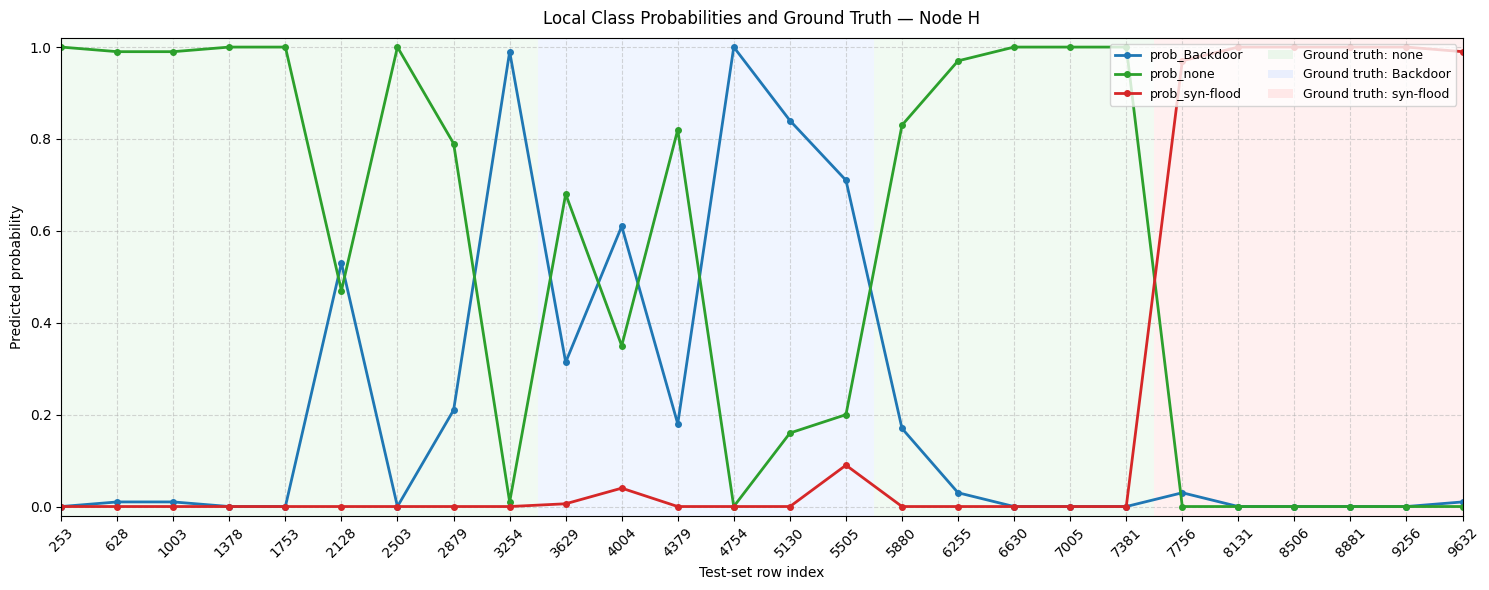

In [60]:
# Cell 7
# =============================================================================
# Plot Local Probabilities vs. Ground Truth Spans Across Sampled Rows (per Node)
# =============================================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]
AUG_DIR = "dataset/normalized/augmented"
PLOTS_DIR = "plots/local_probabilities_per_node"
os.makedirs(PLOTS_DIR, exist_ok=True)

N_SAMPLES = 26
START_ROW = 253

# Ensure node augmented test files are accessible
aug_test_nodes = {}
for node in NODES:
    aug_test_nodes[node] = joblib.load(os.path.join(AUG_DIR, f"Node_{node}_aug_test.pkl"))

probability_colors = {
    "Backdoor": "tab:blue",
    "backdoor": "tab:blue",
    "none": "tab:green",
    "syn-flood": "tab:red",
}

background_colors = {
    "none": "#d8f3dc",
    "Backdoor": "#d6e4ff",
    "backdoor": "#d6e4ff",
    "syn-flood": "#ffd6d6",
}

def normalize_attack_label(value):
    """
    Standardize Attack values into consistent string labels.
    """
    if pd.isna(value):
        return "unknown"
    return str(value).strip()

def add_background_regions(ax, df, sample_rows):
    """
    Add background colored spans based on the true Attack label of each sampled row.
    """
    attack_values = [normalize_attack_label(df.iloc[row]["Attack"]) for row in sample_rows]

    boundaries = np.zeros(len(sample_rows) + 1)
    boundaries[1:-1] = (sample_rows[:-1] + sample_rows[1:]) / 2
    boundaries[0] = sample_rows[0]
    boundaries[-1] = sample_rows[-1]

    start_index = 0
    for i in range(1, len(sample_rows) + 1):
        is_last_sample = (i == len(sample_rows))
        same_label = (attack_values[i] == attack_values[start_index]) if not is_last_sample else False

        if not same_label:
            label = attack_values[start_index]
            color = background_colors.get(label, "#eeeeee")
            ax.axvspan(
                boundaries[start_index],
                boundaries[i],
                facecolor=color,
                alpha=0.35,
                edgecolor="none",
                zorder=0
            )
            start_index = i

# Generate and display plot for each node
for target_node in NODES:
    df_target = aug_test_nodes[target_node].reset_index(drop=True)

    if START_ROW >= len(df_target):
        print(f"Skipping Node {target_node}: START_ROW={START_ROW} exceeds DataFrame length ({len(df_target)}).")
        continue

    sample_rows = np.unique(np.linspace(START_ROW, len(df_target) - 1, N_SAMPLES, dtype=int))

    fig, ax = plt.subplots(figsize=(15, 6))

    # Add ground-truth background
    add_background_regions(ax=ax, df=df_target, sample_rows=sample_rows)

    # Plot local baseline class probabilities
    for cls in classes:
        prob_col = f"prob_{cls}"
        ax.plot(
            sample_rows,
            df_target.iloc[sample_rows][prob_col].to_numpy(),
            marker="o",
            linewidth=2,
            markersize=4,
            label=f"prob_{cls}",
            color=probability_colors.get(cls, "black"),
            zorder=2
        )

    ax.set_title(f"Local Class Probabilities and Ground Truth — Node {target_node}", fontsize=12, pad=10)
    ax.set_xlabel("Test-set row index", fontsize=10)
    ax.set_ylabel("Predicted probability", fontsize=10)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(sample_rows[0], sample_rows[-1])
    ax.set_xticks(sample_rows)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, linestyle="--", alpha=0.5, zorder=1)

    prob_handles, prob_labels = ax.get_legend_handles_labels()
    unique_labels = list(dict.fromkeys([normalize_attack_label(df_target.iloc[r]["Attack"]) for r in sample_rows]))
    ground_truth_handles = [
        Patch(
            facecolor=background_colors.get(lbl, "#eeeeee"),
            edgecolor="none",
            alpha=0.5,
            label=f"Ground truth: {lbl}"
        )
        for lbl in unique_labels
    ]

    ax.legend(handles=prob_handles + ground_truth_handles, loc="upper right", ncol=2, fontsize=9)
    plt.tight_layout()
    
    save_path = os.path.join(PLOTS_DIR, f"local_probabilities_node_{target_node}.png")
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

In [62]:
# Cell 8
# =============================================================================
# Build Node-by-Node Decision Comparison Data
# =============================================================================

import os
import pandas as pd
import numpy as np

MODELS_DIR = "models"
NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]

BASELINE_PATH = os.path.join(
    MODELS_DIR,
    "predictions_test_rf_baseline.csv"
)

if not os.path.exists(BASELINE_PATH):
    raise FileNotFoundError(
        f"Combined baseline prediction file not found: "
        f"{BASELINE_PATH}"
    )

# Load the original combined baseline predictions.
df_pred_base_all = pd.read_csv(BASELINE_PATH)

if len(df_pred_base_all) % len(NODES) != 0:
    raise ValueError(
        f"The combined baseline prediction file contains "
        f"{len(df_pred_base_all)} rows, which cannot be evenly "
        f"split across {len(NODES)} nodes."
    )

ROWS_PER_NODE = len(df_pred_base_all) // len(NODES)

comparison_results = {}

print("Building decision comparison results per node...")

for node_index, node in enumerate(NODES):
    start_index = node_index * ROWS_PER_NODE
    end_index = start_index + ROWS_PER_NODE

    # Select this node's baseline predictions from the combined file.
    df_pred_base = (
        df_pred_base_all
        .iloc[start_index:end_index]
        .reset_index(drop=True)
        .copy()
    )

    hw_agg_path = os.path.join(
        MODELS_DIR,
        f"Node_{node}_predictions_test_rf_context_"
        f"own_hw_plus_agg.csv"
    )

    full_context_path = os.path.join(
        MODELS_DIR,
        f"Node_{node}_predictions_test_rf_context_full.csv"
    )

    if not os.path.exists(hw_agg_path):
        raise FileNotFoundError(
            f"Model 1 prediction file not found: {hw_agg_path}"
        )

    if not os.path.exists(full_context_path):
        raise FileNotFoundError(
            f"Model 2 prediction file not found: "
            f"{full_context_path}"
        )

    df_pred_hw_agg = pd.read_csv(hw_agg_path)
    df_pred_full = pd.read_csv(full_context_path)

    node_lengths = {
        "baseline": len(df_pred_base),
        "hw_agg": len(df_pred_hw_agg),
        "full_context": len(df_pred_full),
    }

    if len(set(node_lengths.values())) != 1:
        raise ValueError(
            f"Prediction row-count mismatch for Node {node}: "
            f"{node_lengths}"
        )

    n_rows = len(df_pred_base)

    required_columns = [
        "Attack",
        "prediction",
        "prob_Backdoor",
        "prob_none",
        "prob_syn-flood",
    ]

    for column in required_columns:
        if column not in df_pred_base.columns:
            raise ValueError(
                f"Column '{column}' not found in combined baseline "
                f"prediction file."
            )

        if column not in df_pred_hw_agg.columns:
            raise ValueError(
                f"Column '{column}' not found in {hw_agg_path}"
            )

        if column not in df_pred_full.columns:
            raise ValueError(
                f"Column '{column}' not found in {full_context_path}"
            )

    # Create the complete comparison DataFrame.
    # All rows are retained, including unchanged rows.
    df_node = pd.DataFrame(
        {
            "row_index": np.arange(n_rows),
            "Attack": df_pred_base["Attack"].to_numpy(),
            "prediction_baseline": (
                df_pred_base["prediction"].to_numpy()
            ),
            "prediction_hw_agg": (
                df_pred_hw_agg["prediction"].to_numpy()
            ),
            "prediction_full": (
                df_pred_full["prediction"].to_numpy()
            ),
        }
    )

    # Store probabilities for all three models.
    for class_name in [
        "Backdoor",
        "none",
        "syn-flood",
    ]:
        df_node[f"prob_base_{class_name}"] = (
            df_pred_base[f"prob_{class_name}"]
            .to_numpy()
        )

        df_node[f"prob_hw_agg_{class_name}"] = (
            df_pred_hw_agg[f"prob_{class_name}"]
            .to_numpy()
        )

        df_node[f"prob_full_{class_name}"] = (
            df_pred_full[f"prob_{class_name}"]
            .to_numpy()
        )

    # Identify decision changes relative to the baseline.
    df_node["change_hw_vs_base"] = (
        df_node["prediction_baseline"]
        != df_node["prediction_hw_agg"]
    )

    df_node["change_full_vs_base"] = (
        df_node["prediction_baseline"]
        != df_node["prediction_full"]
    )

    df_node["change_any_context"] = (
        df_node["change_hw_vs_base"]
        | df_node["change_full_vs_base"]
    )

    # Track correctness against the baseline Attack column.
    df_node["base_correct"] = (
        df_node["prediction_baseline"]
        == df_node["Attack"]
    )

    df_node["hw_agg_correct"] = (
        df_node["prediction_hw_agg"]
        == df_node["Attack"]
    )

    df_node["full_correct"] = (
        df_node["prediction_full"]
        == df_node["Attack"]
    )

    # Always retain the complete node-specific result.
    comparison_results[node] = df_node

    print(
        f"Node {node}: "
        f"{n_rows} total rows, "
        f"{int(df_node['change_hw_vs_base'].sum())} changes "
        f"HW Agg vs Base, "
        f"{int(df_node['change_full_vs_base'].sum())} changes "
        f"Full vs Base"
    )

print("\nComplete node-specific comparison results created.")

Building decision comparison results per node...
Node A: 9633 total rows, 1375 changes HW Agg vs Base, 1259 changes Full vs Base
Node B: 9633 total rows, 1391 changes HW Agg vs Base, 1255 changes Full vs Base
Node C: 9633 total rows, 1506 changes HW Agg vs Base, 1325 changes Full vs Base
Node D: 9633 total rows, 1314 changes HW Agg vs Base, 699 changes Full vs Base
Node E: 9633 total rows, 279 changes HW Agg vs Base, 46 changes Full vs Base
Node F: 9633 total rows, 963 changes HW Agg vs Base, 339 changes Full vs Base
Node G: 9633 total rows, 1072 changes HW Agg vs Base, 160 changes Full vs Base
Node H: 9633 total rows, 1452 changes HW Agg vs Base, 281 changes Full vs Base

Complete node-specific comparison results created.


Node A: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_A.png'


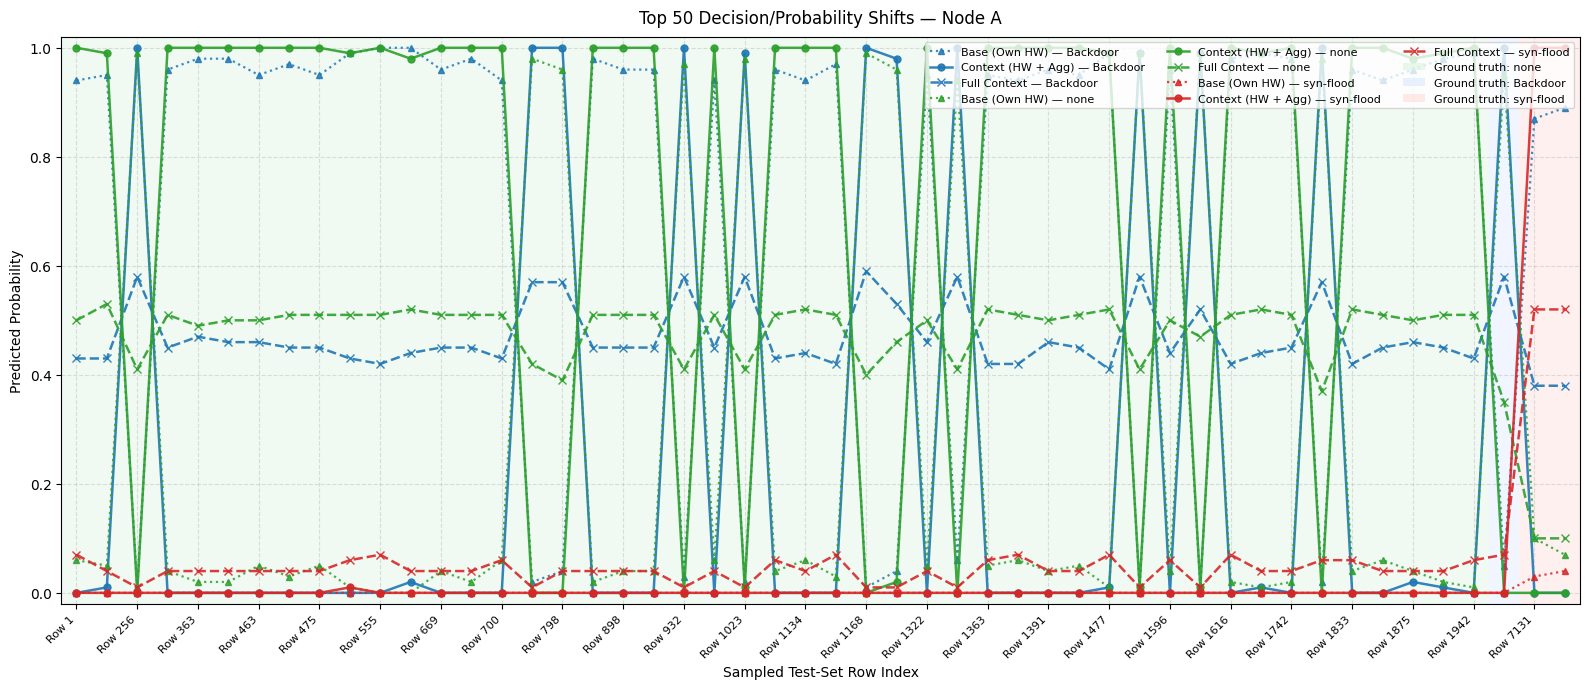

Node B: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_B.png'


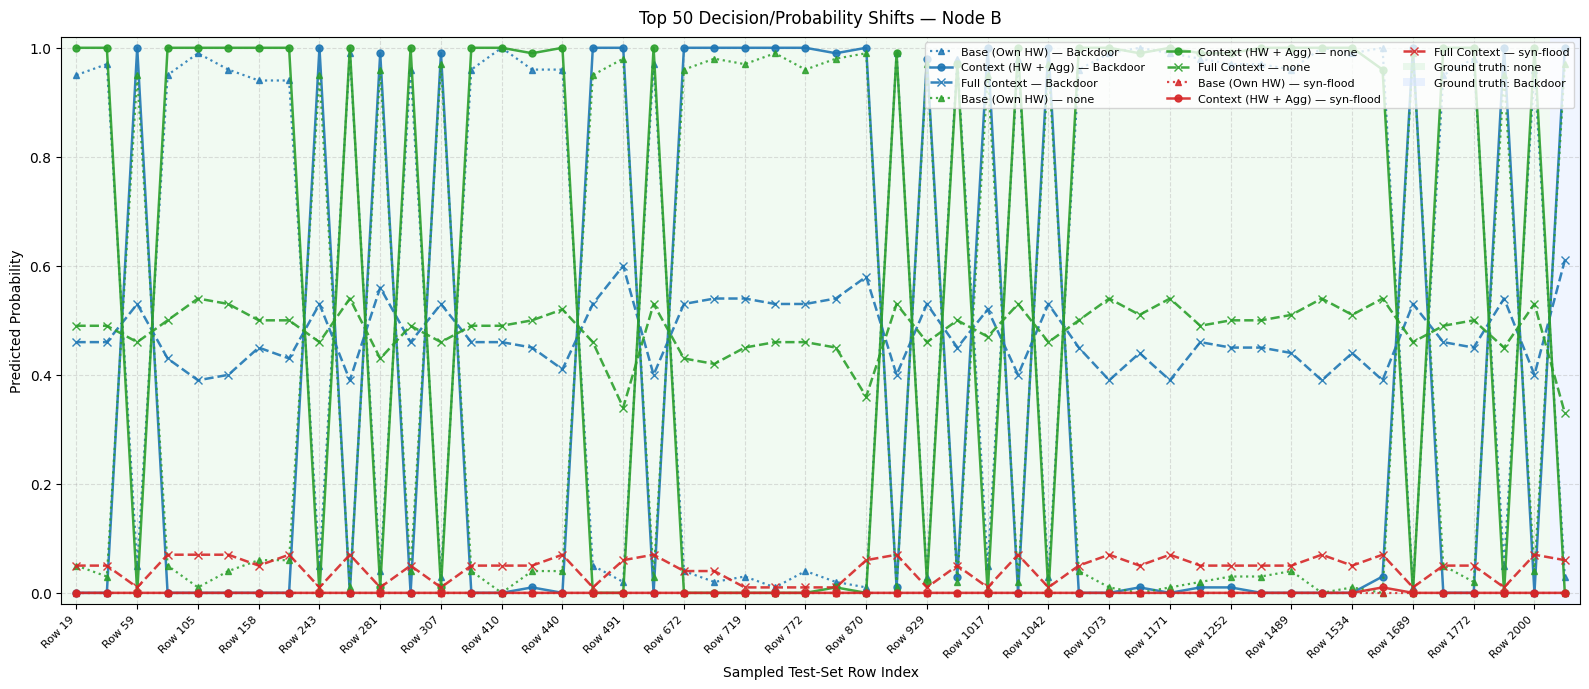

Node C: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_C.png'


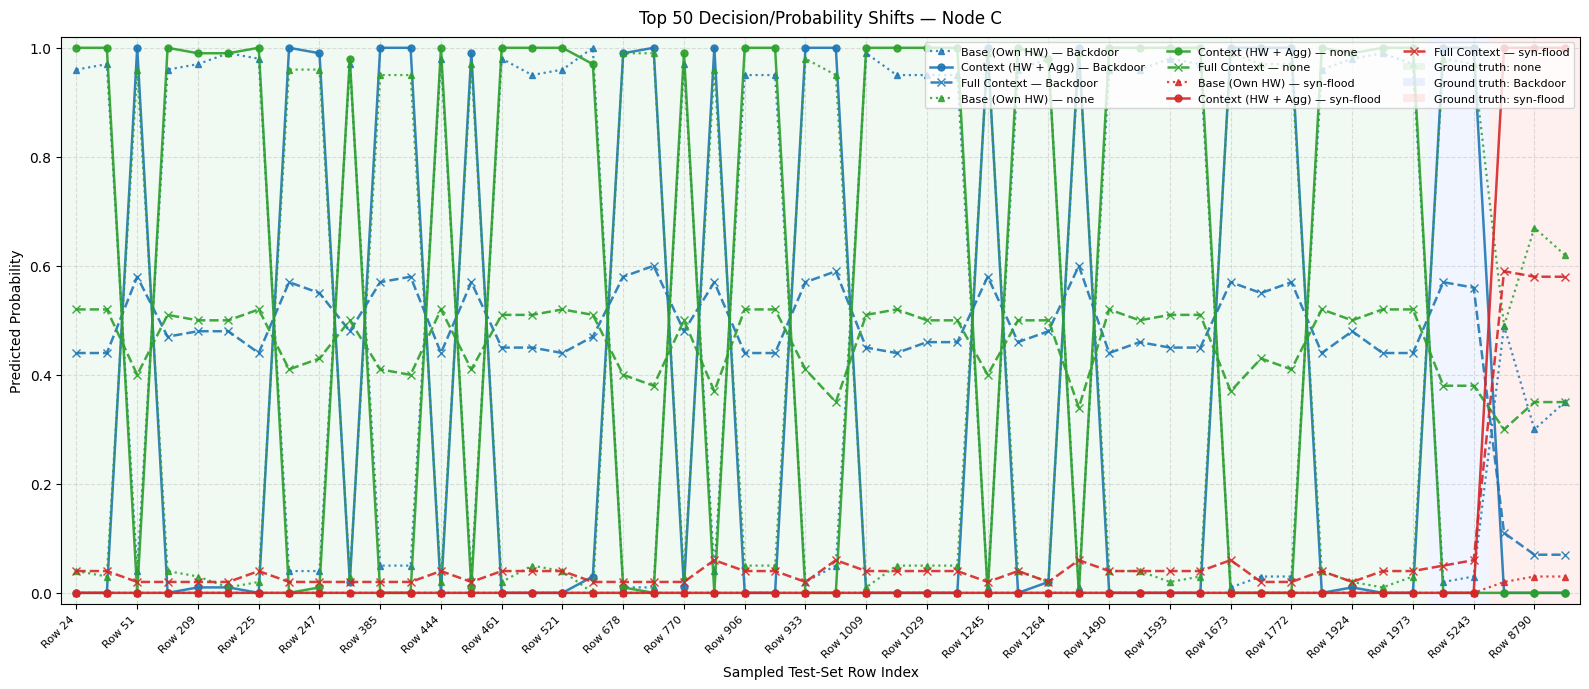

Node D: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_D.png'


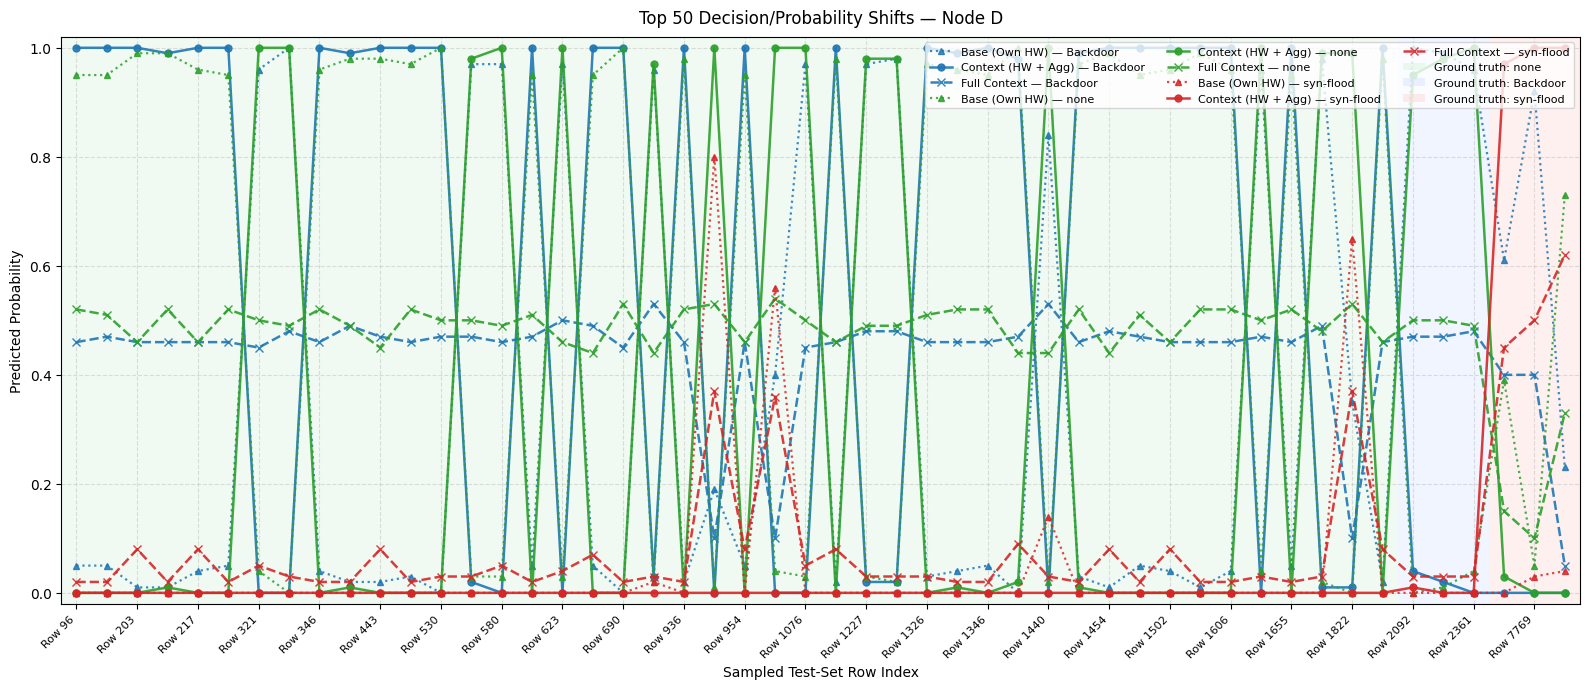

Node E: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_E.png'


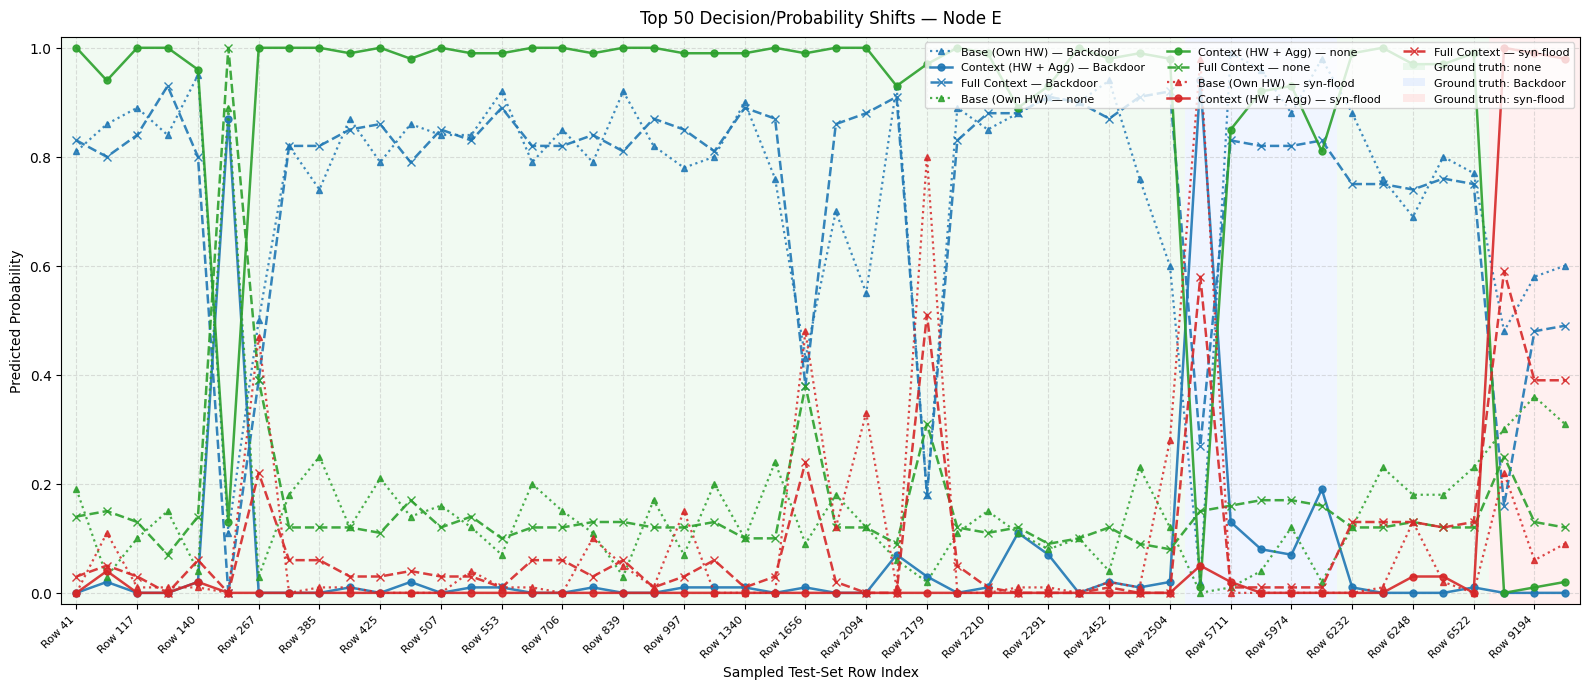

Node F: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_F.png'


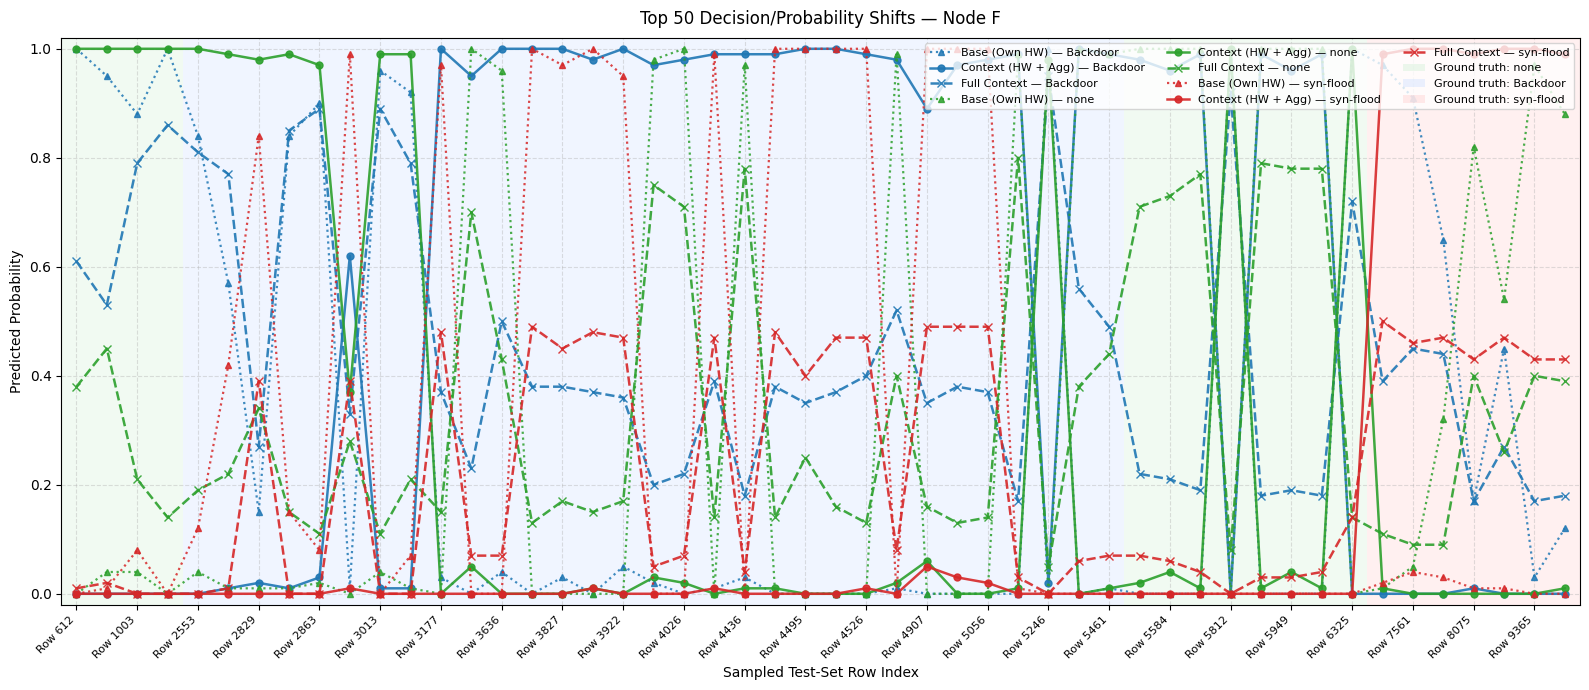

Node G: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_G.png'


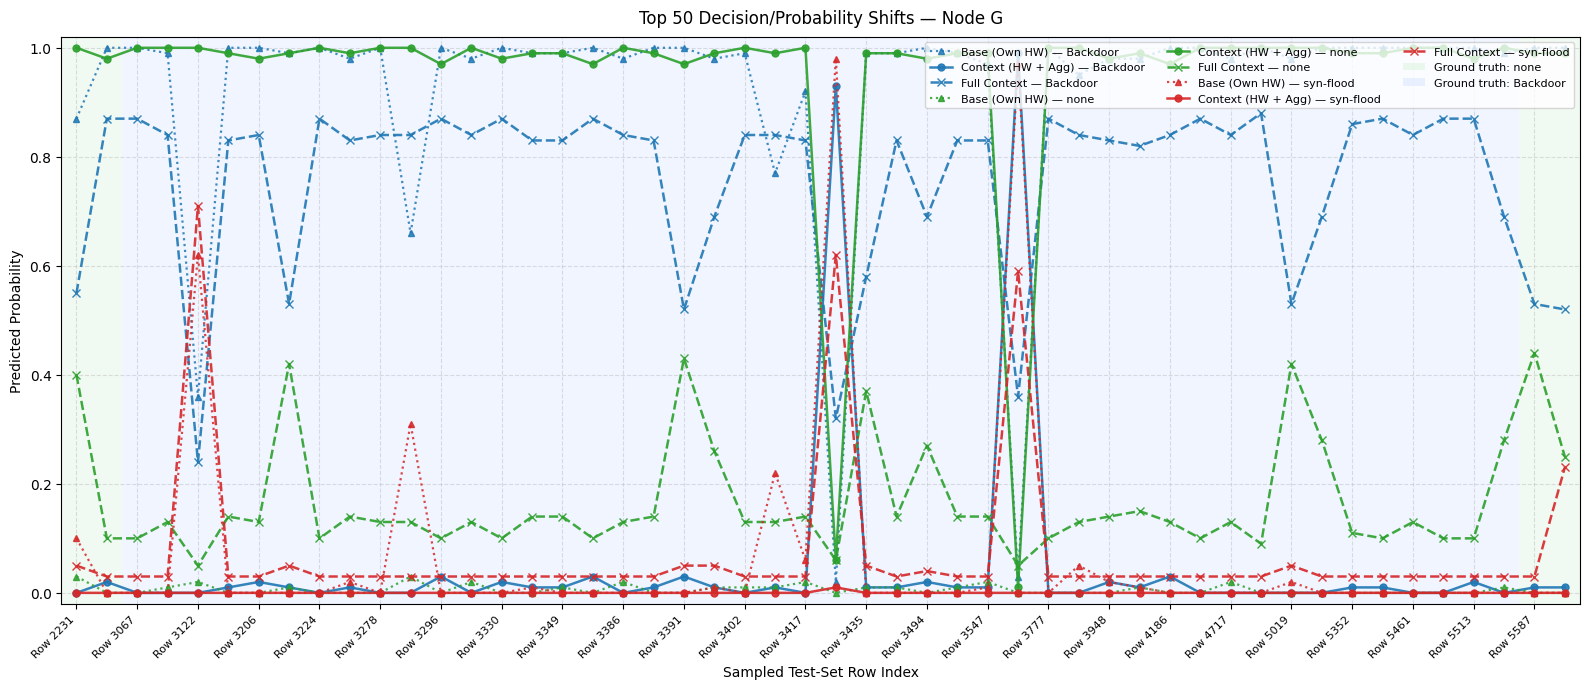

Node H: Saved top 50 shift comparison to 'plots/changed_decisions_per_node/rf_top50_shifts_comparison_node_H.png'


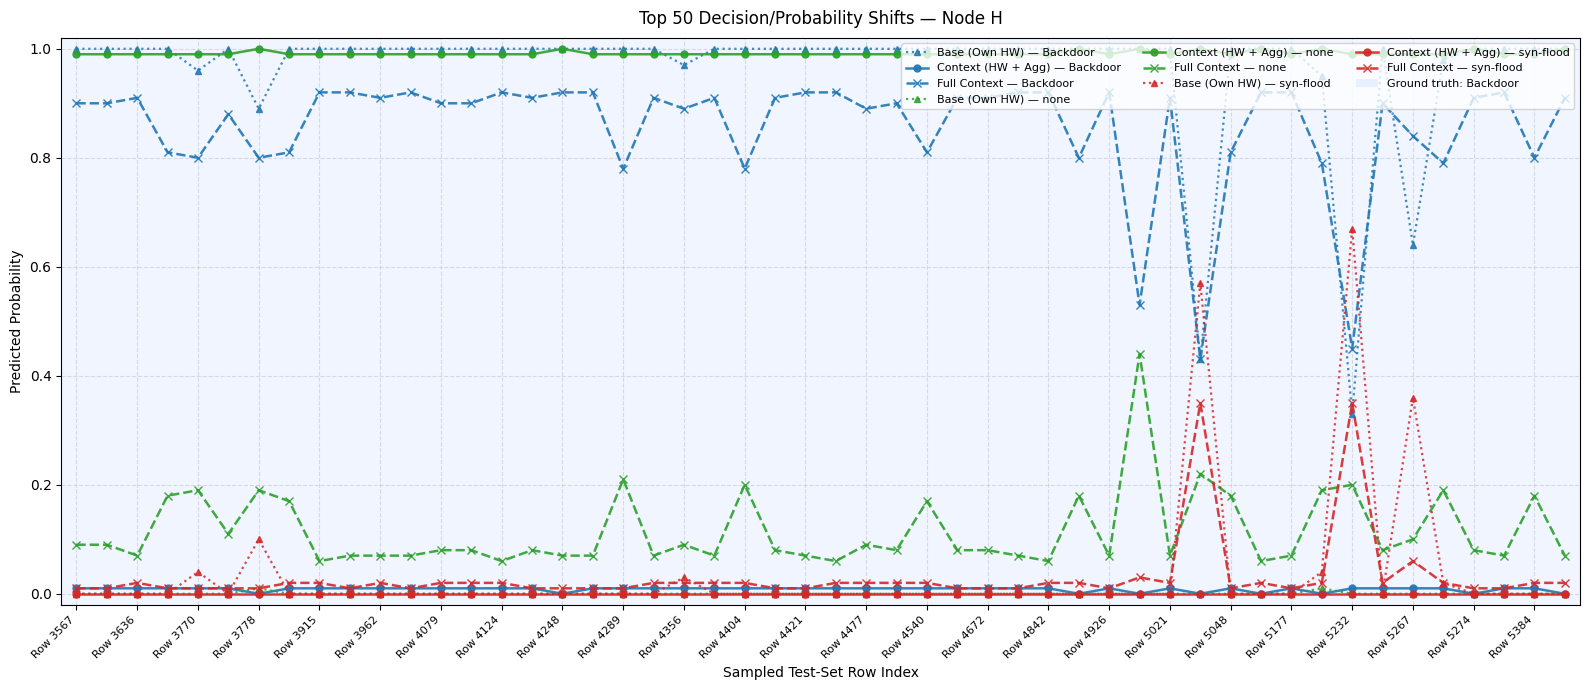

In [63]:
# Cell 9
# =============================================================================
# Plot Probabilities for Top 50 Largest Decision/Probability Shifts per Node
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PLOTS_DIR = "plots/changed_decisions_per_node"
os.makedirs(PLOTS_DIR, exist_ok=True)

TOP_N = 50  # Limit to top 50 highest probability changes

def add_ground_truth_background(ax, df_plot):
    """
    Add background colored spans across categorical sample steps based on true label.
    """
    labels = [str(val).strip() for val in df_plot["Attack"]]
    n_pts = len(labels)
    if n_pts == 0:
        return

    boundaries = np.arange(-0.5, n_pts + 0.5, 1.0)
    region_start = 0

    for i in range(1, n_pts + 1):
        is_last = (i == n_pts)
        if not is_last and labels[i] == labels[region_start]:
            continue

        label = labels[region_start]
        color = background_colors.get(label, "#eeeeee")
        ax.axvspan(
            boundaries[region_start],
            boundaries[i],
            facecolor=color,
            alpha=0.35,
            edgecolor="none",
            zorder=0
        )
        region_start = i

model_line_styles = {
    "base": {"linestyle": ":", "marker": "^", "alpha": 0.85, "lw": 1.6, "prefix": "Base (Own HW)"},
    "hw_agg": {"linestyle": "-", "marker": "o", "alpha": 0.90, "lw": 1.8, "prefix": "Context (HW + Agg)"},
    "full": {"linestyle": "--", "marker": "x", "alpha": 0.90, "lw": 1.8, "prefix": "Full Context"}
}

for target_node in NODES:
    df_node = comparison_results[target_node].copy()

    # Calculate the total absolute probability shift relative to baseline across all classes
    shift_hw = np.zeros(len(df_node))
    shift_full = np.zeros(len(df_node))
    for cls in classes:
        shift_hw += np.abs(df_node[f"prob_hw_agg_{cls}"] - df_node[f"prob_base_{cls}"])
        shift_full += np.abs(df_node[f"prob_full_{cls}"] - df_node[f"prob_base_{cls}"])

    df_node["max_prob_shift"] = np.maximum(shift_hw, shift_full)

    # Filter to changed decision rows or top probability shift rows
    candidate_rows = df_node[df_node["change_any_context"]].copy()
    if len(candidate_rows) < TOP_N:
        candidate_rows = df_node.copy()

    # Select top 50 largest shifts and sort chronologically by test-set row_index
    top_changed = (
        candidate_rows.nlargest(TOP_N, "max_prob_shift")
        .sort_values("row_index")
        .reset_index(drop=True)
    )

    if top_changed.empty:
        print(f"Node {target_node}: No decision changes detected, skipping plot.")
        continue

    # Use categorical integer steps on x-axis to keep visual distance readable
    x_steps = np.arange(len(top_changed))
    x_labels = [f"Row {r}" for r in top_changed["row_index"]]

    fig, ax = plt.subplots(figsize=(16, 7))

    # Add ground-truth background spans
    add_ground_truth_background(ax=ax, df_plot=top_changed)

    # Plot all 3 model probability curves for each class
    for cls in classes:
        color = probability_colors.get(cls, "black")

        # 1. Baseline Model
        ax.plot(
            x_steps, top_changed[f"prob_base_{cls}"],
            color=color,
            linestyle=model_line_styles["base"]["linestyle"],
            marker=model_line_styles["base"]["marker"],
            linewidth=model_line_styles["base"]["lw"],
            markersize=5,
            alpha=model_line_styles["base"]["alpha"],
            label=f"{model_line_styles['base']['prefix']} — {cls}",
            zorder=2
        )

        # 2. Context Model 1 (HW + Agg Context)
        ax.plot(
            x_steps, top_changed[f"prob_hw_agg_{cls}"],
            color=color,
            linestyle=model_line_styles["hw_agg"]["linestyle"],
            marker=model_line_styles["hw_agg"]["marker"],
            linewidth=model_line_styles["hw_agg"]["lw"],
            markersize=5,
            alpha=model_line_styles["hw_agg"]["alpha"],
            label=f"{model_line_styles['hw_agg']['prefix']} — {cls}",
            zorder=2
        )

        # 3. Full Context Model
        ax.plot(
            x_steps, top_changed[f"prob_full_{cls}"],
            color=color,
            linestyle=model_line_styles["full"]["linestyle"],
            marker=model_line_styles["full"]["marker"],
            linewidth=model_line_styles["full"]["lw"],
            markersize=6,
            alpha=model_line_styles["full"]["alpha"],
            label=f"{model_line_styles['full']['prefix']} — {cls}",
            zorder=2
        )

    # Ground-truth patches for legend
    present_labels = list(dict.fromkeys([str(val).strip() for val in top_changed["Attack"]]))
    ground_truth_handles = [
        Patch(
            facecolor=background_colors.get(lbl, "#eeeeee"),
            edgecolor="none",
            alpha=0.5,
            label=f"Ground truth: {lbl}"
        )
        for lbl in present_labels
    ]

    ax.set_title(
        f"Top {len(top_changed)} Decision/Probability Shifts — Node {target_node}",
        fontsize=12,
        pad=10
    )
    ax.set_xlabel("Sampled Test-Set Row Index", fontsize=10)
    ax.set_ylabel("Predicted Probability", fontsize=10)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(-0.5, len(top_changed) - 0.5)

    # Label every 2nd tick on the x-axis to keep text readable
    ax.set_xticks(x_steps[::2])
    ax.set_xticklabels(x_labels[::2], rotation=45, ha="right", fontsize=8)

    ax.grid(True, linestyle="--", alpha=0.4, zorder=1)

    model_handles, model_labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=model_handles + ground_truth_handles,
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
        ncol=3,
        fontsize=8
    )

    plt.tight_layout()
    output_path = os.path.join(PLOTS_DIR, f"rf_top50_shifts_comparison_node_{target_node}.png")
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Node {target_node}: Saved top {len(top_changed)} shift comparison to '{output_path}'")
    plt.show()
    plt.close(fig)

Node A: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_A.png'


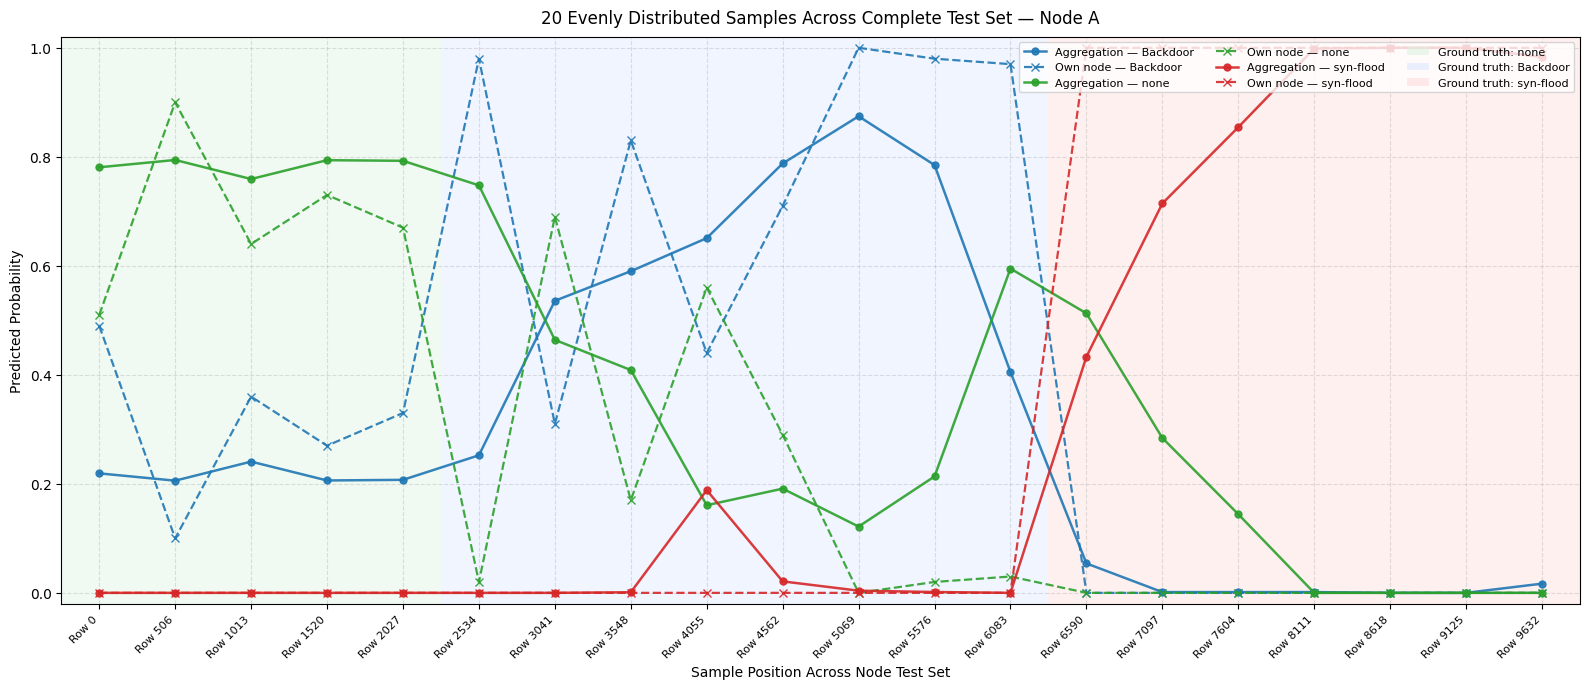

Node B: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_B.png'


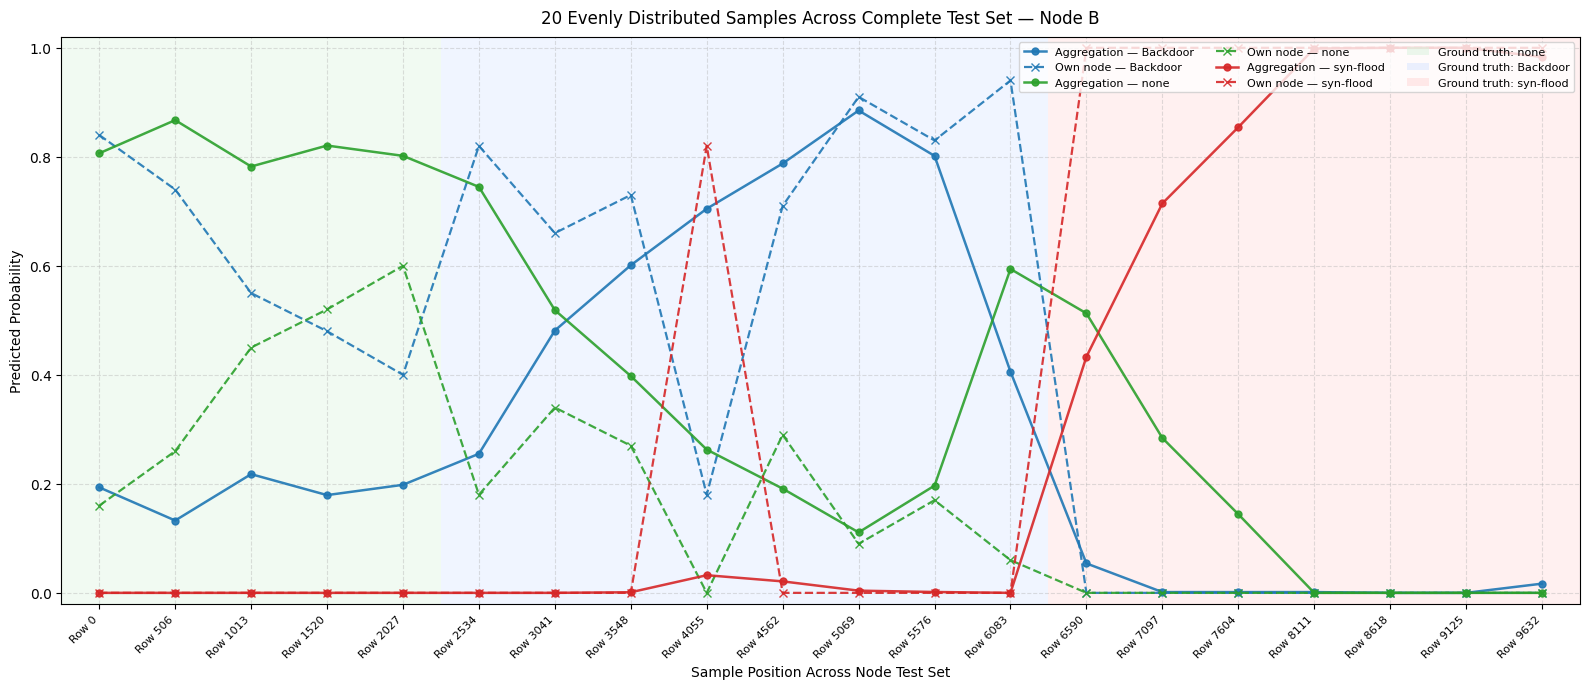

Node C: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_C.png'


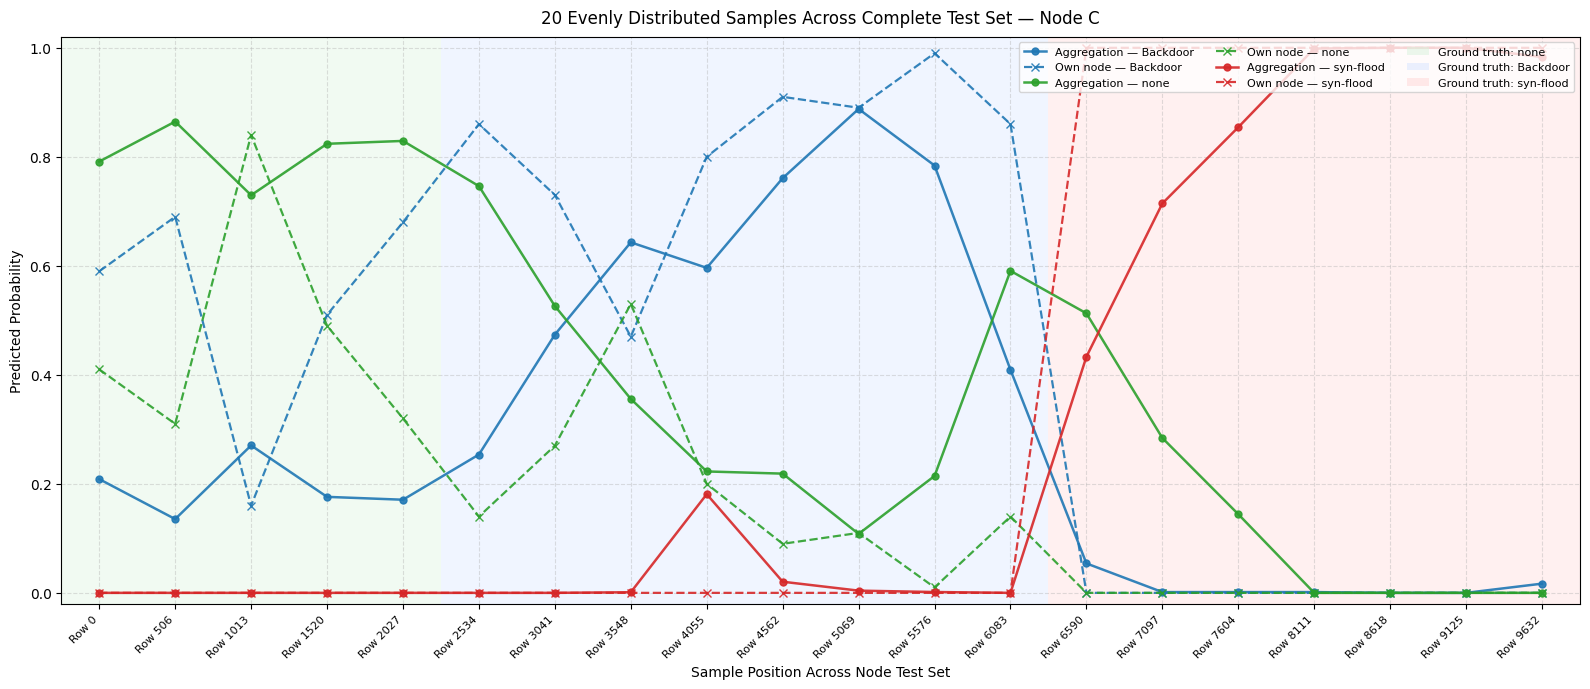

Node D: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_D.png'


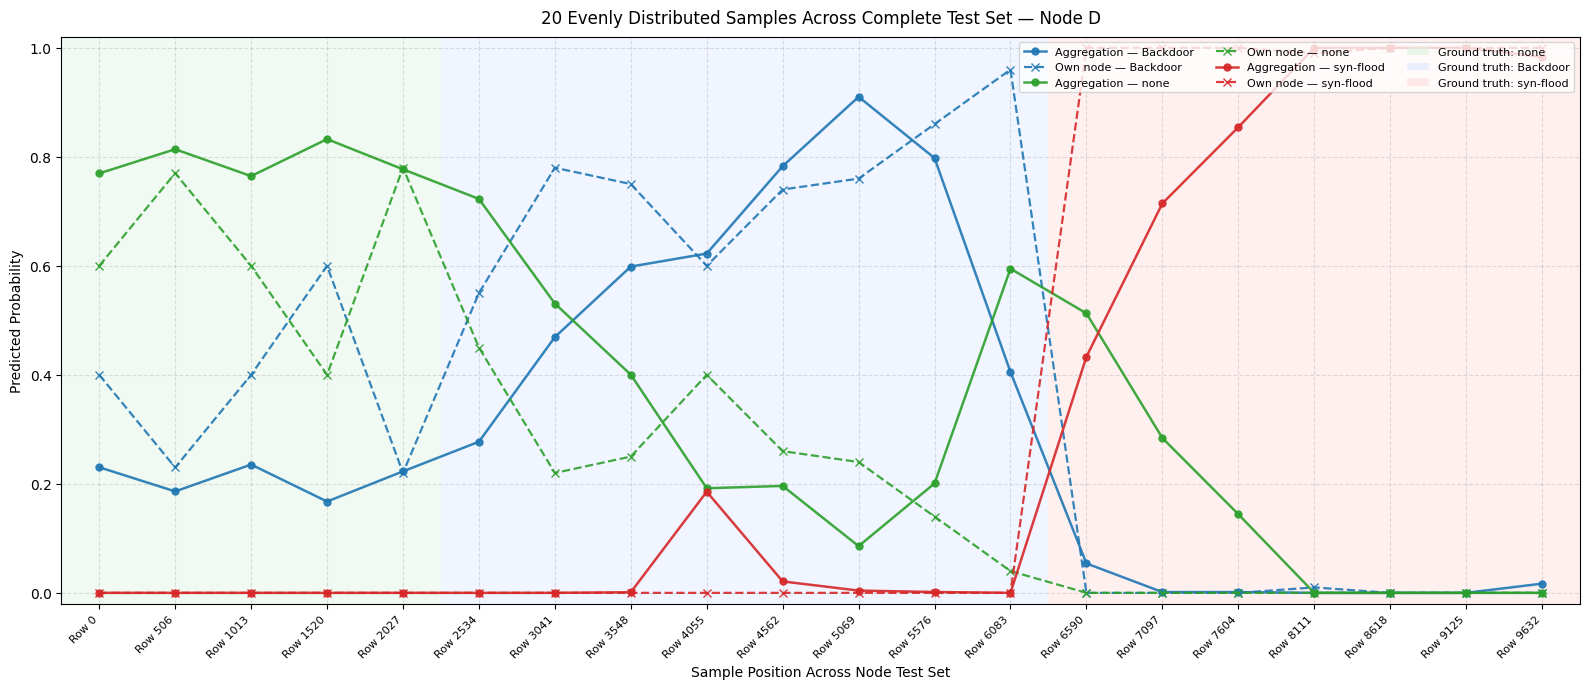

Node E: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_E.png'


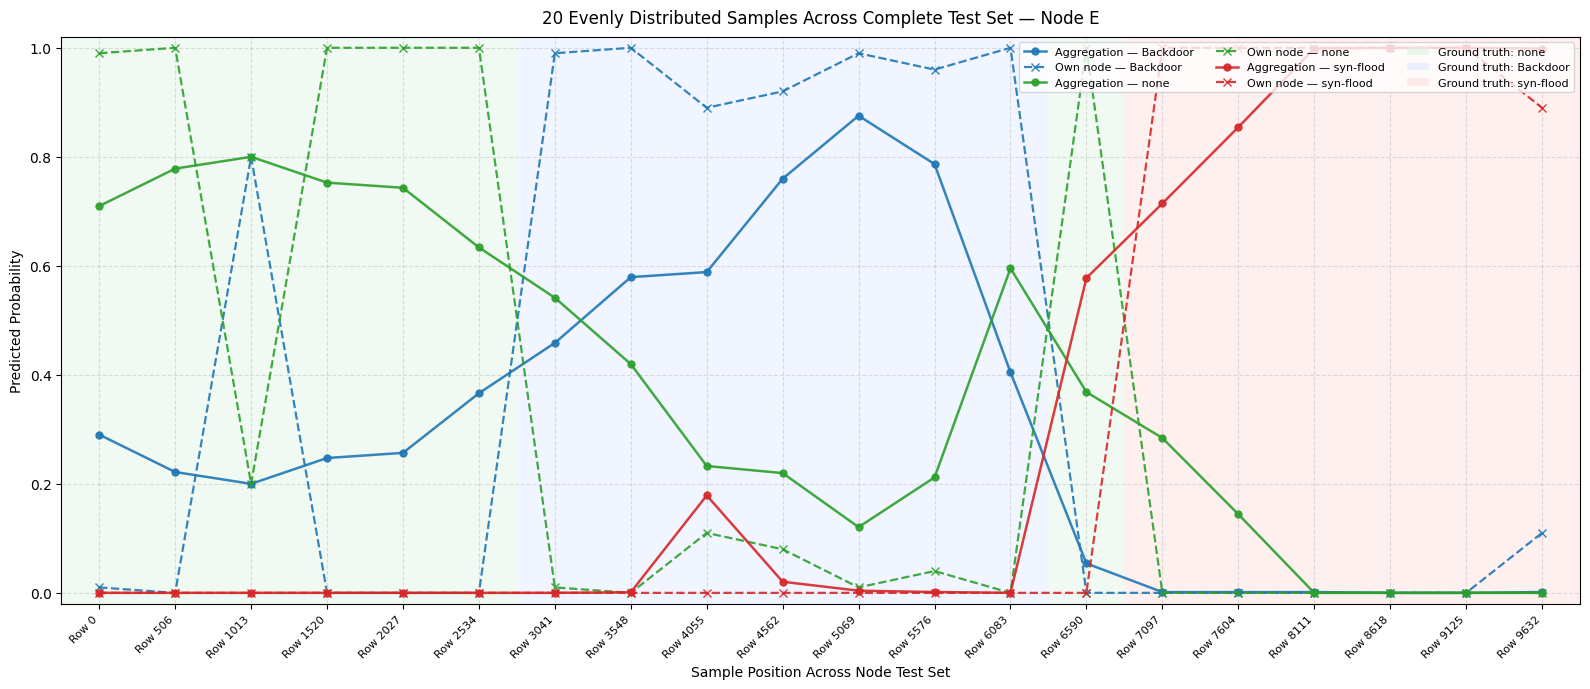

Node F: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_F.png'


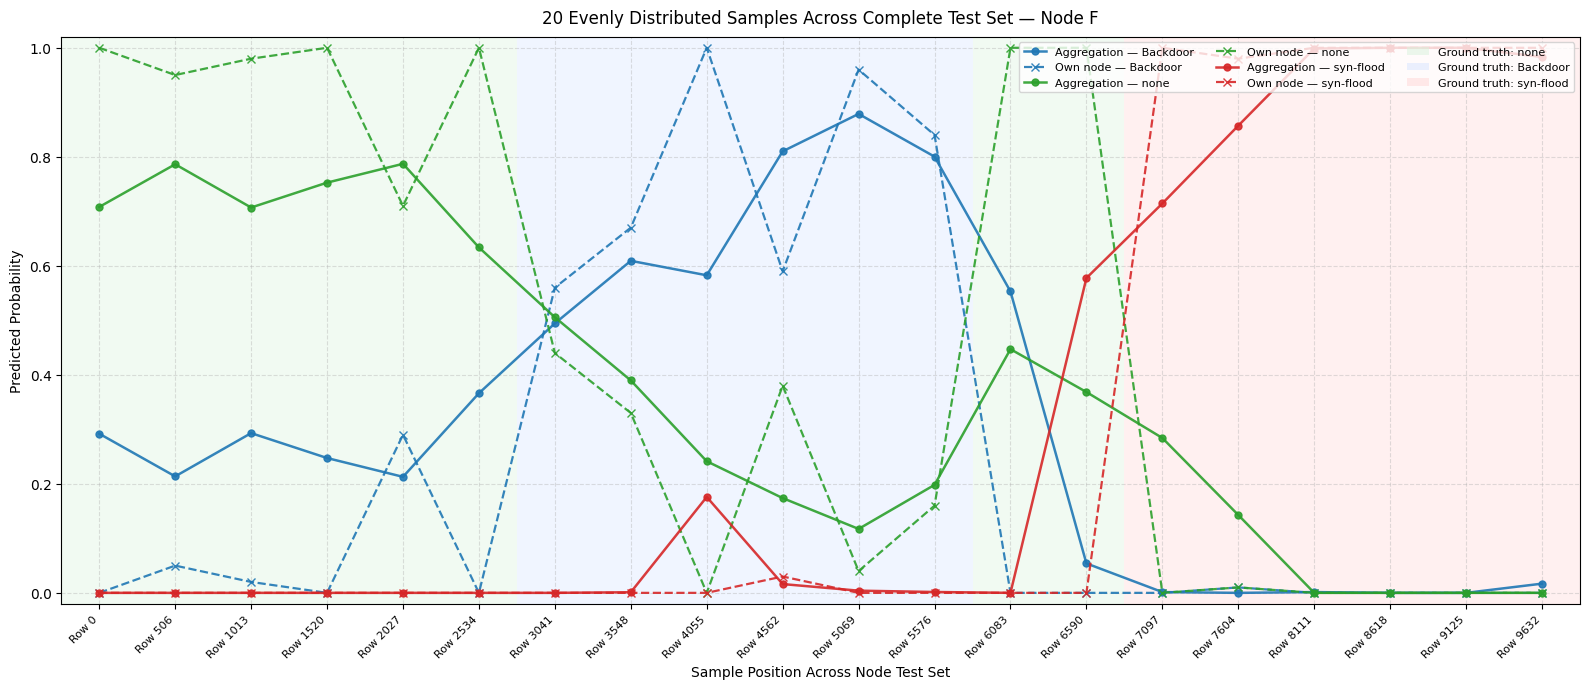

Node G: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_G.png'


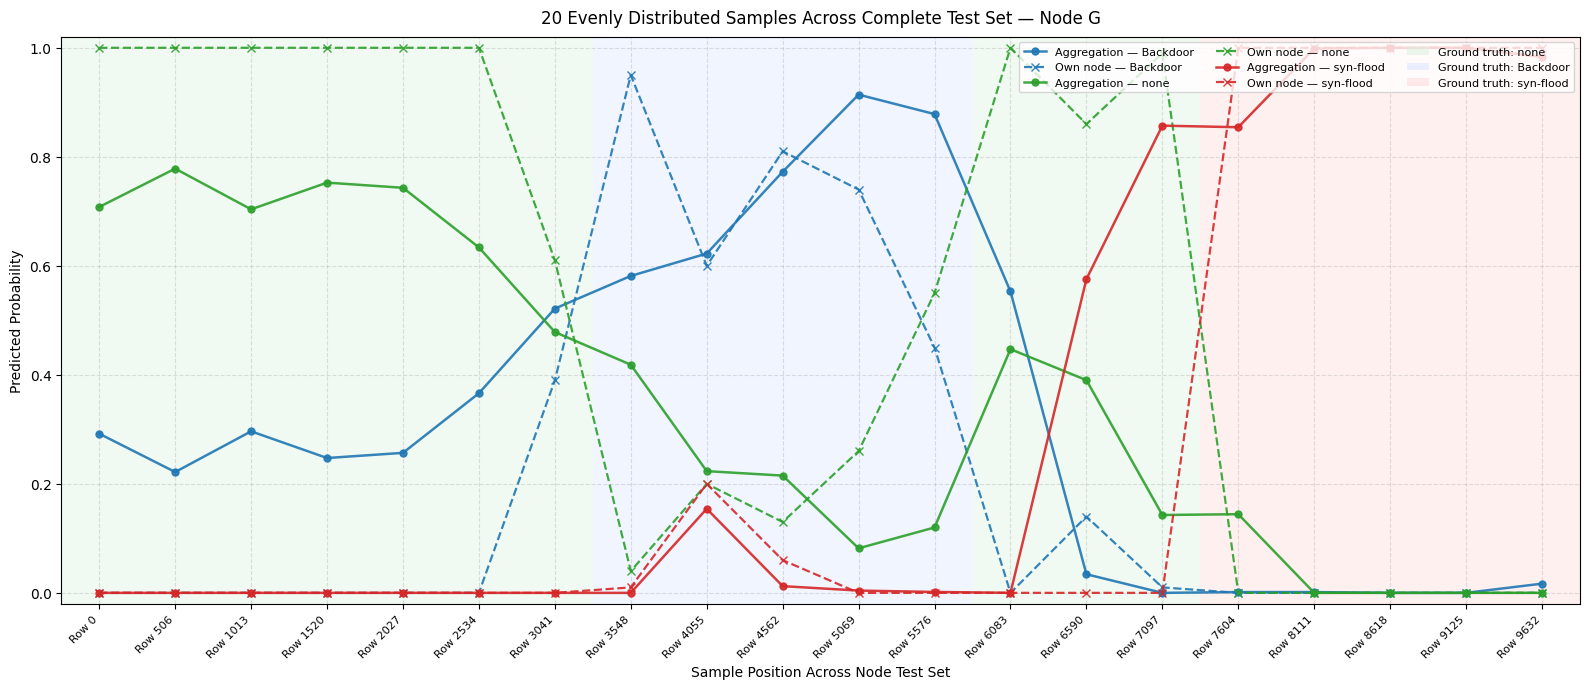

Node H: Saved 20 evenly spaced samples to 'plots/changed_decisions_per_node/rf_30_evenly_spaced_aggregation_vs_own_node_node_H.png'


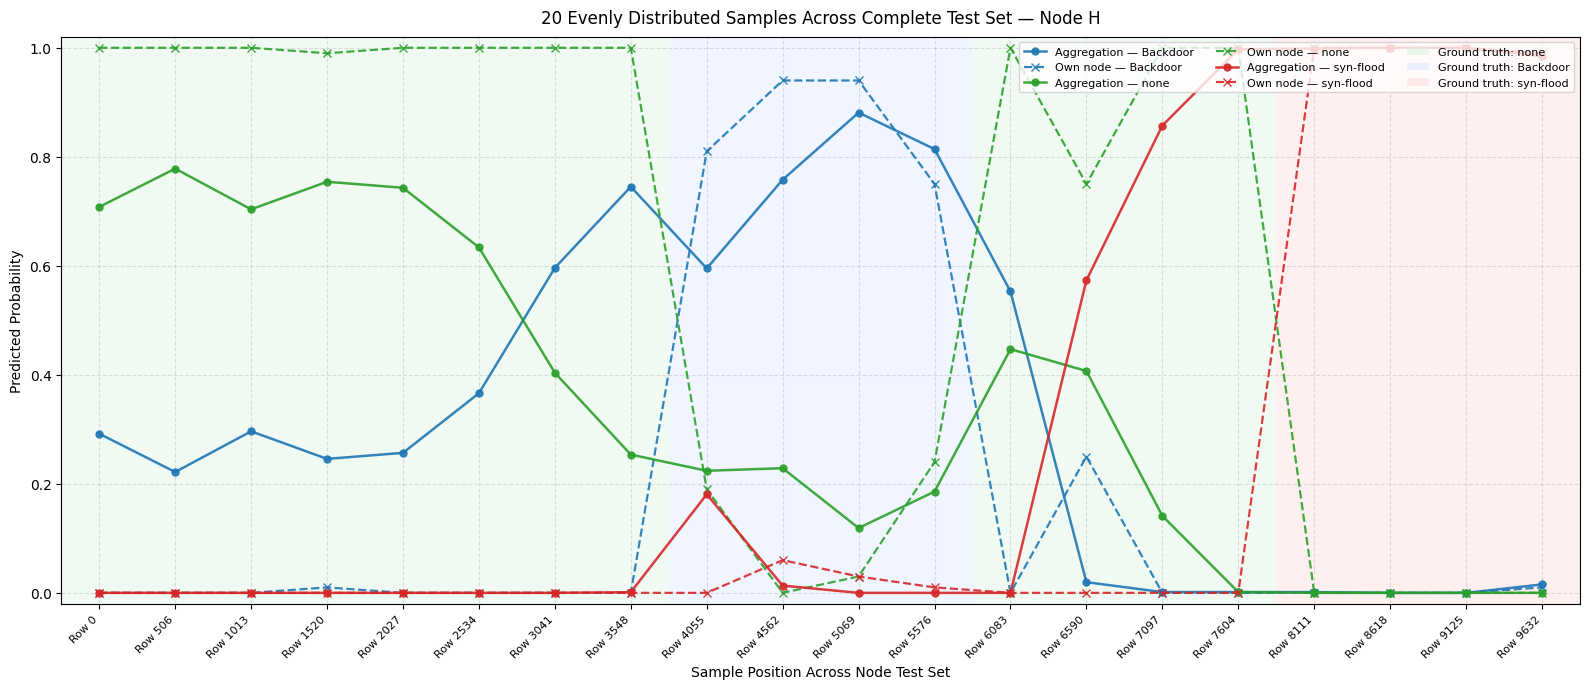

In [64]:
# Cell 9
# =============================================================================
# Plot Aggregation and Own-Node Attack Probabilities
# for 30 Evenly Distributed Samples Per Node Test Set
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

PLOTS_DIR = "plots/changed_decisions_per_node"
os.makedirs(PLOTS_DIR, exist_ok=True)

N_SAMPLES = 20

AUGMENTED_TEST_DIR = (
    "dataset/normalized/augmented_csv"
)

ATTACK_PROB_DIR = (
    "dataset/normalized/attack_prob"
)

agg_prob_cols = [
    "agg_prob_Backdoor",
    "agg_prob_none",
    "agg_prob_syn-flood",
]

own_prob_cols = [
    "prob_Backdoor",
    "prob_none",
    "prob_syn-flood",
]

probability_colors = {
    "Backdoor": "#1f77b4",
    "none": "#2ca02c",
    "syn-flood": "#d62728",
}

model_styles = {
    "aggregation": {
        "linestyle": "-",
        "marker": "o",
        "linewidth": 1.8,
        "markersize": 5,
        "alpha": 0.9,
    },
    "own_node": {
        "linestyle": "--",
        "marker": "x",
        "linewidth": 1.6,
        "markersize": 6,
        "alpha": 0.9,
    },
}


def add_ground_truth_background(ax, df_plot):
    """
    Add background-colored spans based on consecutive ground-truth labels.
    """
    labels = [
        str(value).strip()
        for value in df_plot["Attack"]
    ]

    n_points = len(labels)

    if n_points == 0:
        return

    boundaries = np.arange(
        -0.5,
        n_points + 0.5,
        1.0,
    )

    region_start = 0

    for i in range(1, n_points + 1):
        is_last = i == n_points

        if not is_last and labels[i] == labels[region_start]:
            continue

        label = labels[region_start]

        color = background_colors.get(
            label,
            "#eeeeee",
        )

        ax.axvspan(
            boundaries[region_start],
            boundaries[i],
            facecolor=color,
            alpha=0.35,
            edgecolor="none",
            zorder=0,
        )

        region_start = i


for target_node in NODES:
    node_key = str(target_node).replace(
        "Node_",
        "",
    ).upper()

    # Load the node-specific augmented test CSV.
    augmented_test_path = os.path.join(
        AUGMENTED_TEST_DIR,
        f"Node_{node_key}_combined_augmented_test.csv",
    )

    if not os.path.exists(augmented_test_path):
        raise FileNotFoundError(
            f"Node-specific augmented test file not found: "
            f"{augmented_test_path}"
        )

    df_agg_node = pd.read_csv(
        augmented_test_path,
        index_col=0,
    )

    # Use the Attack column from the node-specific augmented test CSV.
    if "Attack" not in df_agg_node.columns:
        raise ValueError(
            f"Column 'Attack' not found in "
            f"{augmented_test_path}."
        )

    # Validate aggregation probability columns.
    for col in agg_prob_cols:
        if col not in df_agg_node.columns:
            raise ValueError(
                f"Column '{col}' not found in "
                f"{augmented_test_path}."
            )

    # Load the own-node attack probabilities.
    own_prob_path = os.path.join(
        ATTACK_PROB_DIR,
        f"Node_{node_key}_test_normalized.csv",
    )

    if not os.path.exists(own_prob_path):
        raise FileNotFoundError(
            f"Own-node probability file not found: {own_prob_path}"
        )

    df_own_node = pd.read_csv(
        own_prob_path,
        index_col=0,
    )

    # Validate own-node probability columns.
    for col in own_prob_cols:
        if col not in df_own_node.columns:
            raise ValueError(
                f"Column '{col}' not found in {own_prob_path}."
            )

    if len(df_agg_node) != len(df_own_node):
        raise ValueError(
            f"Row-count mismatch for Node {node_key}: "
            f"augmented test data contains {len(df_agg_node)} rows, "
            f"but own-node probabilities contain "
            f"{len(df_own_node)} rows."
        )

    # Load comparison results and keep only the test-set rows.
    df_node = (
        comparison_results[target_node]
        .reset_index(drop=True)
        .iloc[:len(df_agg_node)]
        .copy()
    )

    if len(df_node) != len(df_agg_node):
        raise ValueError(
            f"Comparison results for Node {target_node} contain "
            f"{len(df_node)} test rows, while the augmented test "
            f"dataset contains {len(df_agg_node)} rows."
        )

    # Replace the comparison-results ground truth explicitly.
    # The source of truth is the node-specific augmented test CSV.
    df_node["Attack"] = (
        df_agg_node["Attack"]
        .reset_index(drop=True)
        .to_numpy()
    )

    # Add aggregation probabilities.
    for col in agg_prob_cols:
        df_node[col] = (
            df_agg_node[col]
            .reset_index(drop=True)
            .to_numpy()
        )

    # Add own-node probabilities.
    for col in own_prob_cols:
        df_node[col] = (
            df_own_node[col]
            .reset_index(drop=True)
            .to_numpy()
        )

    # Calculate the total probability shift across all classes.
    probability_shift = np.zeros(len(df_node))

    for agg_col, own_col in zip(
        agg_prob_cols,
        own_prob_cols,
    ):
        probability_shift += (
            df_node[agg_col] - df_node[own_col]
        ).abs().to_numpy()

    df_node["probability_shift"] = probability_shift

    # Select evenly distributed samples across this node's complete test set.
    n_selected = min(
        N_SAMPLES,
        len(df_node),
    )

    selected_positions = np.linspace(
        0,
        len(df_node) - 1,
        num=n_selected,
        dtype=int,
    )

    selected_rows = (
        df_node
        .iloc[selected_positions]
        .copy()
        .reset_index(drop=True)
    )

    if selected_rows.empty:
        print(
            f"Node {target_node}: No rows available. "
            "Skipping plot."
        )
        continue

    x_steps = np.arange(len(selected_rows))

    if "row_index" in selected_rows.columns:
        x_labels = [
            f"Row {int(row_index)}"
            for row_index in selected_rows["row_index"]
        ]
    else:
        x_labels = [
            f"Row {int(row_index)}"
            for row_index in selected_positions
        ]

    fig, ax = plt.subplots(
        figsize=(16, 7),
    )

    add_ground_truth_background(
        ax=ax,
        df_plot=selected_rows,
    )

    # Plot aggregation and own-node probabilities for all classes.
    for class_name in [
        "Backdoor",
        "none",
        "syn-flood",
    ]:
        color = probability_colors[class_name]

        agg_col = f"agg_prob_{class_name}"
        own_col = f"prob_{class_name}"

        ax.plot(
            x_steps,
            selected_rows[agg_col],
            color=color,
            linestyle=model_styles["aggregation"]["linestyle"],
            marker=model_styles["aggregation"]["marker"],
            linewidth=model_styles["aggregation"]["linewidth"],
            markersize=model_styles["aggregation"]["markersize"],
            alpha=model_styles["aggregation"]["alpha"],
            label=f"Aggregation — {class_name}",
            zorder=2,
        )

        ax.plot(
            x_steps,
            selected_rows[own_col],
            color=color,
            linestyle=model_styles["own_node"]["linestyle"],
            marker=model_styles["own_node"]["marker"],
            linewidth=model_styles["own_node"]["linewidth"],
            markersize=model_styles["own_node"]["markersize"],
            alpha=model_styles["own_node"]["alpha"],
            label=f"Own node — {class_name}",
            zorder=2,
        )

    present_labels = list(
        dict.fromkeys(
            str(value).strip()
            for value in selected_rows["Attack"]
        )
    )

    ground_truth_handles = [
        Patch(
            facecolor=background_colors.get(
                label,
                "#eeeeee",
            ),
            edgecolor="none",
            alpha=0.5,
            label=f"Ground truth: {label}",
        )
        for label in present_labels
    ]

    ax.set_title(
        f"{len(selected_rows)} Evenly Distributed Samples "
        f"Across Complete Test Set — Node {target_node}",
        fontsize=12,
        pad=10,
    )

    ax.set_xlabel(
        "Sample Position Across Node Test Set",
        fontsize=10,
    )

    ax.set_ylabel(
        "Predicted Probability",
        fontsize=10,
    )

    ax.set_ylim(
        -0.02,
        1.02,
    )

    ax.set_xlim(
        -0.5,
        len(selected_rows) - 0.5,
    )

    ax.set_xticks(x_steps)

    ax.set_xticklabels(
        x_labels,
        rotation=45,
        ha="right",
        fontsize=8,
    )

    ax.grid(
        True,
        linestyle="--",
        alpha=0.4,
        zorder=1,
    )

    probability_handles, probability_labels = (
        ax.get_legend_handles_labels()
    )

    ax.legend(
        handles=(
            probability_handles
            + ground_truth_handles
        ),
        loc="upper right",
        bbox_to_anchor=(1.0, 1.0),
        ncol=3,
        fontsize=8,
    )

    plt.tight_layout()

    output_path = os.path.join(
        PLOTS_DIR,
        f"rf_30_evenly_spaced_"
        f"aggregation_vs_own_node_node_{node_key}.png",
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"Node {target_node}: Saved "
        f"{len(selected_rows)} evenly spaced samples to "
        f"'{output_path}'"
    )

    plt.show()
    plt.close(fig)

In [65]:
# Cell 10
# =============================================================================
# Summary of Decision Shift Impact (Corrected Errors vs. Introduced Errors)
# =============================================================================

import pandas as pd
from IPython.display import display

summary_shifts = []

for node in NODES:
    df_n = comparison_results[node]
    
    # Model 1 (HW + Agg Context) impact
    hw_fixed = ((~df_n["base_correct"]) & (df_n["hw_agg_correct"])).sum()
    hw_broken = ((df_n["base_correct"]) & (~df_n["hw_agg_correct"])).sum()
    hw_net = hw_fixed - hw_broken
    
    # Model 2 (Full Context) impact
    full_fixed = ((~df_n["base_correct"]) & (df_n["full_correct"])).sum()
    full_broken = ((df_n["base_correct"]) & (~df_n["full_correct"])).sum()
    full_net = full_fixed - full_broken
    
    summary_shifts.append({
        "Node": node,
        "Total Test Rows": len(df_n),
        "HW+Agg Total Changed": df_n["change_hw_vs_base"].sum(),
        "HW+Agg Errors Corrected": hw_fixed,
        "HW+Agg Errors Introduced": hw_broken,
        "HW+Agg Net Gain": hw_net,
        "Full Total Changed": df_n["change_full_vs_base"].sum(),
        "Full Errors Corrected": full_fixed,
        "Full Errors Introduced": full_broken,
        "Full Net Gain": full_net,
    })

df_shift_summary = pd.DataFrame(summary_shifts)

# Calculate total / summary row across all nodes
totals = {
    "Node": "Total",
    "Total Test Rows": df_shift_summary["Total Test Rows"].sum(),
    "HW+Agg Total Changed": df_shift_summary["HW+Agg Total Changed"].sum(),
    "HW+Agg Errors Corrected": df_shift_summary["HW+Agg Errors Corrected"].sum(),
    "HW+Agg Errors Introduced": df_shift_summary["HW+Agg Errors Introduced"].sum(),
    "HW+Agg Net Gain": df_shift_summary["HW+Agg Net Gain"].sum(),
    "Full Total Changed": df_shift_summary["Full Total Changed"].sum(),
    "Full Errors Corrected": df_shift_summary["Full Errors Corrected"].sum(),
    "Full Errors Introduced": df_shift_summary["Full Errors Introduced"].sum(),
    "Full Net Gain": df_shift_summary["Full Net Gain"].sum(),
}

df_shift_summary = pd.concat([df_shift_summary, pd.DataFrame([totals])], ignore_index=True)

# Render formatted HTML table in Jupyter Notebook
styled_table = (
    df_shift_summary.style
    .set_caption("Summary of Impact on Baseline Mistakes per Node")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "15px"), ("font-weight", "bold"), ("text-align", "center"), ("padding-bottom", "10px")]},
        {"selector": "th", "props": [("text-align", "center"), ("background-color", "#f2f2f2"), ("padding", "8px"), ("border", "1px solid #ddd")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "8px"), ("border", "1px solid #ddd")]},
    ])
    .hide(axis="index")
)

display(styled_table)

Node,Total Test Rows,HW+Agg Total Changed,HW+Agg Errors Corrected,HW+Agg Errors Introduced,HW+Agg Net Gain,Full Total Changed,Full Errors Corrected,Full Errors Introduced,Full Net Gain
A,9633,1375,1033,342,691,1259,975,284,691
B,9633,1391,1093,298,795,1255,1024,231,793
C,9633,1506,1111,395,716,1325,1001,324,677
D,9633,1314,749,563,186,699,535,162,373
E,9633,279,228,50,178,46,35,9,26
F,9633,963,683,273,410,339,335,4,331
G,9633,1072,553,498,55,160,155,4,151
H,9633,1452,310,1077,-767,281,243,16,227
Total,77064,9352,5760,3496,2264,5364,4303,1034,3269
